# Búsqueda de cortes óptimos

In [ ]:
import pandas as pd

df_sin_analisis = pd.read_pickle("df_sin_analisis.pkl")

In [152]:
import pandas as pd
import numpy as np

# Base recomendada para este paso
base = df_sin_analisis.copy()

target = "GDM1"

# Predictores que has estado usando en pruebas
predictores = [
    "diabetes franca 1T",
    "etnia",
    "factores riesgo",
    "edad",
    "bmi",
    "1t glucosa",
    "1T hemoglobina glicada"
]

# Variables binarias derivadas a excluir explícitamente
derivadas_binarias = ["obesidad", "edad>=35", "gluc 1t>100", "hba1c 1t>5,7"]

# Verificación de columnas
cols_necesarias = [target] + predictores
faltantes = [c for c in cols_necesarias if c not in base.columns]
if faltantes:
    raise ValueError(f"Faltan columnas en la base: {faltantes}")

# Construcción del df final continuo
df_final_cont = base[cols_necesarias].copy()

# Limpieza básica de tipos para facilitar cortes posteriores
for c in ["edad", "bmi", "1t glucosa", "1T hemoglobina glicada", "factores riesgo"]:
    if c in df_final_cont.columns:
        df_final_cont[c] = pd.to_numeric(df_final_cont[c], errors="coerce")

# Asegurar target binario numérico
df_final_cont[target] = df_final_cont[target].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    df_final_cont.drop(columns=[target]),
    df_final_cont[target],
    test_size=0.2,
    random_state=42,
    stratify=df_final_cont[target]
)

# Comprobaciones rápidas
print("Shape df_final_cont:", df_final_cont.shape)
print("Columnas:", df_final_cont.columns.tolist())
print("\nNulos por columna:")
print(df_final_cont.isna().sum().sort_values(ascending=False))

Shape df_final_cont: (1878, 8)
Columnas: ['GDM1', 'diabetes franca 1T', 'etnia', 'factores riesgo', 'edad', 'bmi', '1t glucosa', '1T hemoglobina glicada']

Nulos por columna:
GDM1                      0
diabetes franca 1T        0
etnia                     0
factores riesgo           0
edad                      0
bmi                       0
1t glucosa                0
1T hemoglobina glicada    0
dtype: int64


### Comenzar primero con acote de cortes mediante RL

In [153]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import pandas as pd
import numpy as np
import warnings

class ThresholdBinarizer(BaseEstimator, TransformerMixin):
    """Transforma columna continua en binaria según umbral.
    Sobrescribe la columna original o crea nueva columna.
    """
    def __init__(self, col=None, threshold=None, drop_original=True):
        self.col = col
        self.threshold = threshold
        self.drop_original = drop_original

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        if self.col is None or self.col not in X.columns:
            return X
        vals = pd.to_numeric(X[self.col], errors="coerce")
        X[self.col] = (vals >= float(self.threshold)).astype(int).fillna(0)
        return X

def preprocesador_base_dinamico(escalar_numericas=False):
    """Selecciona columnas por dtype en tiempo de fit (evita errores si cambian nombres)."""
    pasos_num = [("imputer", SimpleImputer(strategy="median"))]
    if escalar_numericas:
        pasos_num.append(("scaler", StandardScaler()))
    
    pre = ColumnTransformer(
        transformers=[
            ("num", Pipeline(pasos_num), make_column_selector(dtype_include=np.number)),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore", drop="if_binary", sparse_output=False))
            ]), make_column_selector(dtype_exclude=np.number)),
        ],
        remainder="drop"
    )
    return pre

In [154]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)
from sklearn.compose import ColumnTransformer, make_column_selector
import numpy as np

cv_grid = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

scoring_grid = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "f1": "f1"
}

resultados_grid_cv = []
resultados_grid_params = []

def columnas_modelo(X_df):
    num_cols = [
        c for c in X_df.columns
        if pd.api.types.is_numeric_dtype(X_df[c]) and not pd.api.types.is_bool_dtype(X_df[c])
    ]
    cat_cols = [c for c in X_df.columns if c not in num_cols]
    return num_cols, cat_cols

def preprocesador_base_dinamico(escalar_numericas=False):
    pasos_num = [("imputer", SimpleImputer(strategy="median"))]
    if escalar_numericas:
        pasos_num.append(("scaler", StandardScaler()))
    pre = ColumnTransformer(
        transformers=[
            ("num", Pipeline(pasos_num), make_column_selector(dtype_include=np.number)),
            ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                              ("onehot", OneHotEncoder(handle_unknown="ignore", drop="if_binary", sparse_output=False))]),
             make_column_selector(dtype_exclude=np.number)),
        ],
        remainder="drop"
    )
    return pre

def registrar_resultados(nombre, grid, dibujar=True):
    """Extrae resultados SOLO de CV (sin test)"""
    idx = grid.best_index_

    for metrica in ["roc_auc", "pr_auc", "f1"]:
        mean = grid.cv_results_[f"mean_test_{metrica}"][idx]
        std = grid.cv_results_[f"std_test_{metrica}"][idx]
        ci95 = 1.96 * std / np.sqrt(cv_grid.get_n_splits())

        resultados_grid_cv.append({
            "modelo": nombre,
            "metrica": metrica,
            "mean": mean,
            "std": std,
            "ci95_low": mean - ci95,
            "ci95_high": mean + ci95
        })

    resultados_grid_params.append({
        "modelo": nombre,
        "best_params": str(grid.best_params_)
    })

    print(f"{nombre} mejor configuración: {grid.best_params_}")
    mean_roc = grid.cv_results_[f"mean_test_roc_auc"][idx]
    std_roc = grid.cv_results_[f"std_test_roc_auc"][idx]
    print(f"{nombre} ROC-AUC (CV): {mean_roc:.4f} ± {std_roc:.4f}")

    if dibujar:
        # Usar cross_val_predict para plots
        cv_plot = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            y_pred_cv = cross_val_predict(grid.best_estimator_, X_train, y_train, cv=cv_plot)
            y_proba_cv = cross_val_predict(grid.best_estimator_, X_train, y_train, cv=cv_plot, method="predict_proba")[:, 1]

        roc_auc_cv = roc_auc_score(y_train, y_proba_cv)

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        cm = confusion_matrix(y_train, y_pred_cv)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Sí"])
        disp.plot(ax=axes[0], cmap="Blues", colorbar=False, values_format="d")
        axes[0].set_title(f"Matriz de confusión - {nombre} (CV)")

        fpr, tpr, _ = roc_curve(y_train, y_proba_cv)
        axes[1].plot(fpr, tpr, label=f"{nombre} (AUC = {roc_auc_cv:.3f})", linewidth=2)
        axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Clasificador aleatorio")
        axes[1].set_xlabel("FPR (1 - especificidad)")
        axes[1].set_ylabel("TPR (sensibilidad)")
        axes[1].set_title(f"Curva ROC - {nombre} (CV)")
        axes[1].legend()
        axes[1].grid(alpha=0.25)

        plt.tight_layout()
        plt.show()

In [155]:
# Celda 43: Generación candidatos (sin cambios)
import numpy as np
import pandas as pd

vars_cont = ["bmi", "edad", "1T hemoglobina glicada", "1t glucosa"]

clinicos = {
    "bmi": [30],
    "edad": [35],
    "1T hemoglobina glicada": [5.7],
    "1t glucosa": [100]
}

def generar_candidatos(X, col, pcts=[20, 30, 40, 50, 60, 70, 80, 90]):
    vals = pd.to_numeric(X[col].dropna(), errors="coerce")
    pvals = np.percentile(vals, pcts) if len(vals) > 0 else []
    candidatos = sorted(set(list(pvals) + clinicos.get(col, [])))
    return [float(round(x, 3)) for x in candidatos]

candidatos_univariados = {v: generar_candidatos(X_train, v) for v in vars_cont}
for v, cand in candidatos_univariados.items():
    print(f"{v}: {len(cand)} candidatos → {cand}")

bmi: 9 candidatos → [21.751, 23.017, 24.224, 25.747, 27.617, 29.988, 30.0, 31.93, 34.742]
edad: 9 candidatos → [29.0, 31.0, 33.0, 34.0, 35.0, 36.0, 37.0, 38.0, 41.0]
1T hemoglobina glicada: 9 candidatos → [5.0, 5.1, 5.2, 5.25, 5.3, 5.4, 5.5, 5.6, 5.7]
1t glucosa: 9 candidatos → [71.0, 74.0, 76.0, 78.0, 80.0, 82.0, 84.0, 89.0, 100.0]



=== Buscando cortes univariados para: bmi ===
Corte Univar - BMI mejor configuración: {'binar__threshold': 24.224}
Corte Univar - BMI ROC-AUC (CV): 0.7675 ± 0.0440


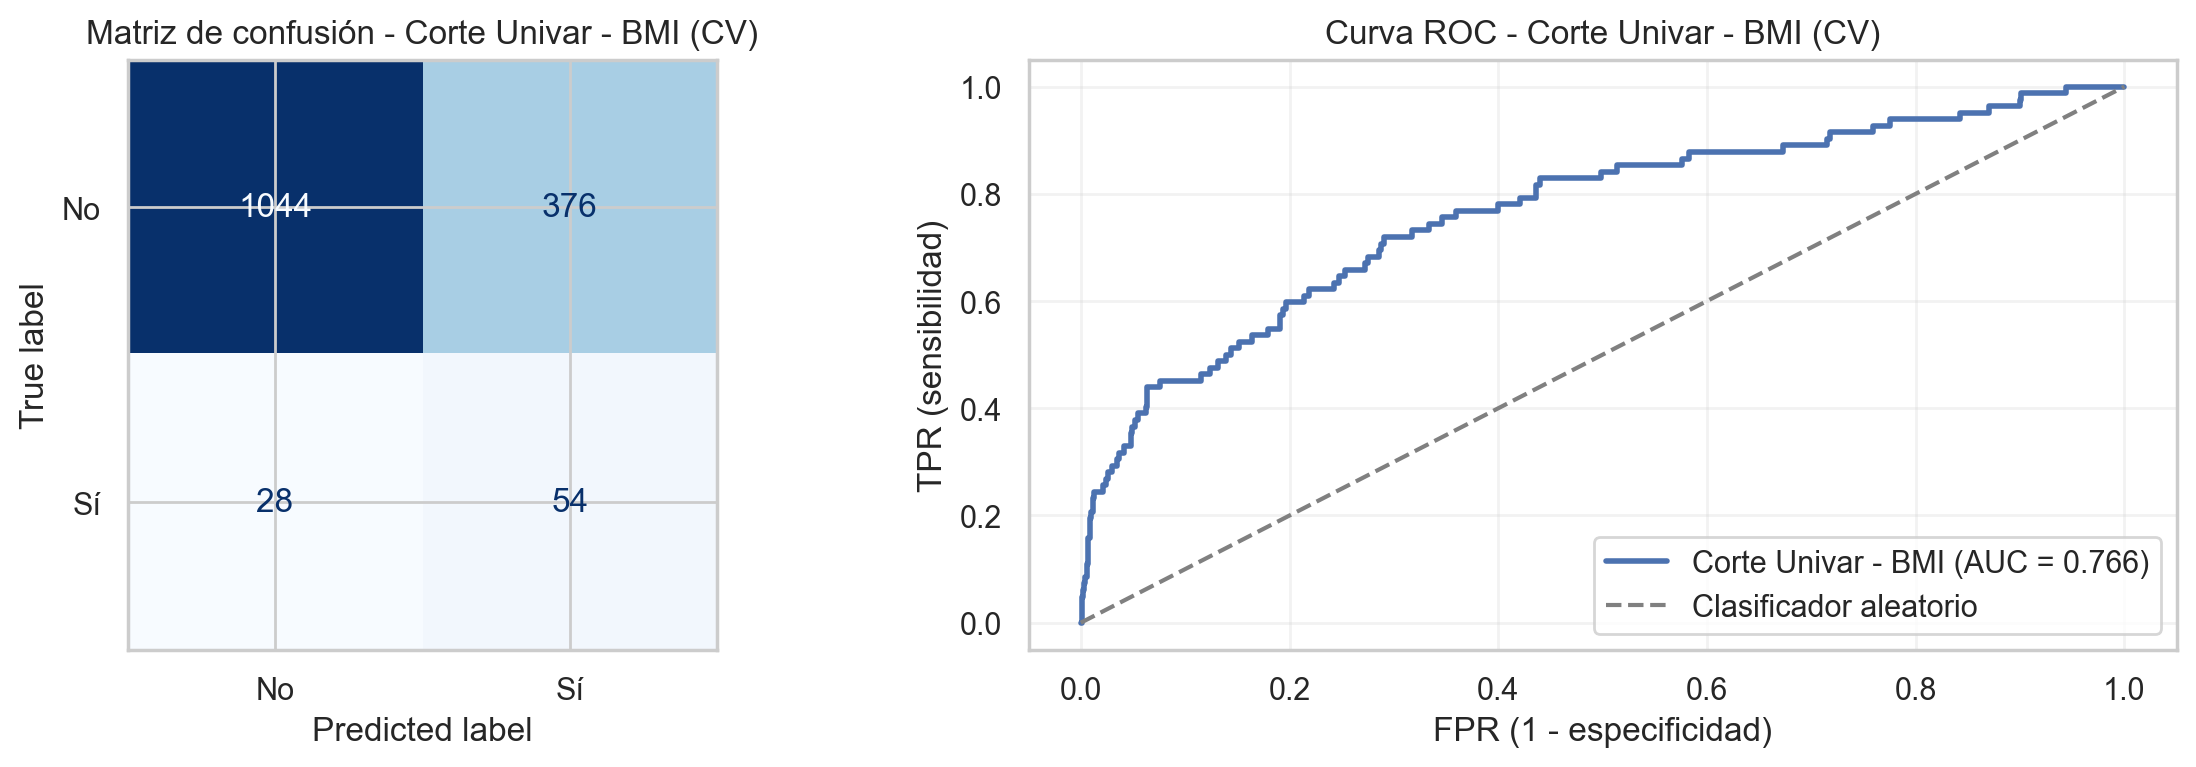


Top-5 cortes para BMI:


,threshold,roc_auc_cv,pr_auc_cv,f1_cv
0,24.224,0.7675,0.3114,0.1997
1,30.000,0.7610,0.3097,0.1983
2,29.988,0.7604,0.3101,0.1993
3,25.747,0.7588,0.3123,0.2046
4,23.017,0.7556,0.3093,0.1946


In [156]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

print("\n=== Buscando cortes univariados para: bmi ===")

pipe_bmi = Pipeline([
    ("binar", ThresholdBinarizer(col="bmi", drop_original=True)),
    ("prep", preprocesador_base_dinamico(escalar_numericas=False)),
    ("clf", LogisticRegression(max_iter=5000, class_weight="balanced", solver="liblinear"))
])

param_grid_bmi = {"binar__threshold": candidatos_univariados["bmi"]}

grid_bmi = GridSearchCV(
    estimator=pipe_bmi,
    param_grid=param_grid_bmi,
    scoring=scoring_grid,
    refit="roc_auc",
    cv=cv_grid,
    n_jobs=-1,
    verbose=0
)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    grid_bmi.fit(X_train, y_train)

registrar_resultados("Corte Univar - BMI", grid_bmi, dibujar=True)

idxs = np.argsort(grid_bmi.cv_results_["mean_test_roc_auc"])[::-1][:5]
top_bmi = pd.DataFrame({
    "threshold": [grid_bmi.cv_results_["param_binar__threshold"][i] for i in idxs],
    "roc_auc_cv": [grid_bmi.cv_results_["mean_test_roc_auc"][i] for i in idxs],
    "pr_auc_cv": [grid_bmi.cv_results_["mean_test_pr_auc"][i] for i in idxs],
    "f1_cv": [grid_bmi.cv_results_["mean_test_f1"][i] for i in idxs],
})
print("\nTop-5 cortes para BMI:")
display(top_bmi.round(4))


=== Buscando cortes univariados para: edad ===
Corte Univar - Edad mejor configuración: {'binar__threshold': 29.0}
Corte Univar - Edad ROC-AUC (CV): 0.7587 ± 0.0464


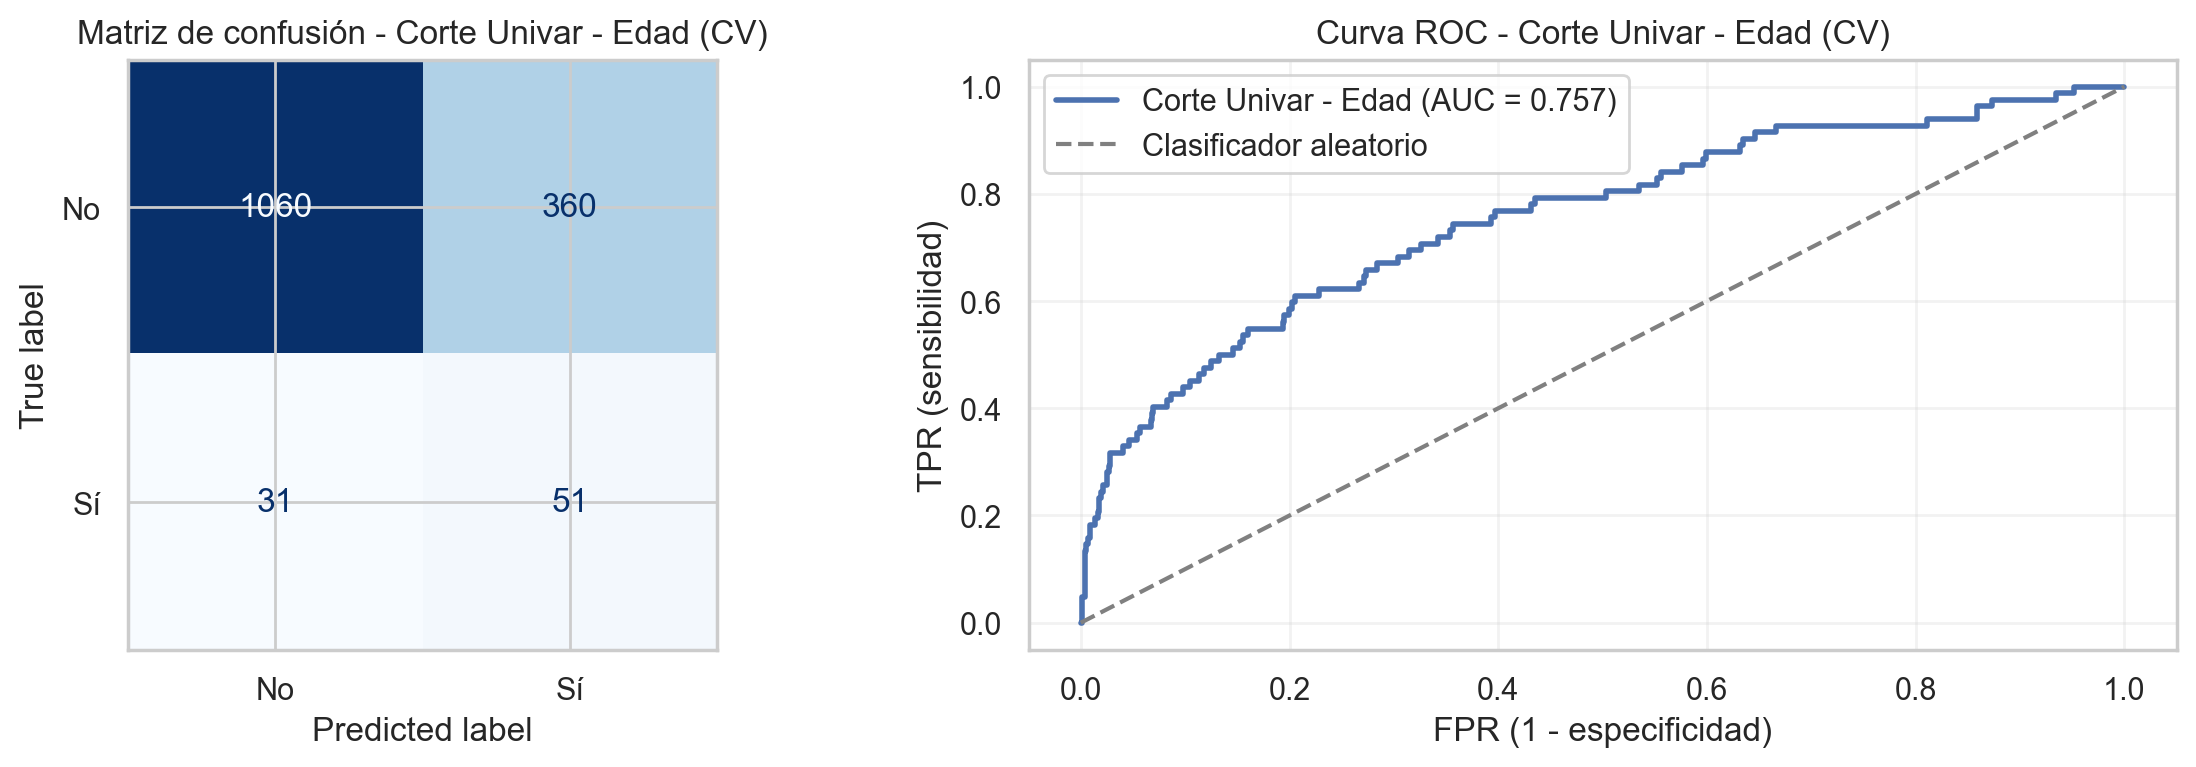


Top-5 cortes para Edad:


,threshold,roc_auc_cv,pr_auc_cv,f1_cv
0,29.0,0.7587,0.3082,0.2085
1,37.0,0.7576,0.2992,0.2027
2,38.0,0.7572,0.2904,0.2024
3,41.0,0.7521,0.2953,0.2040
4,34.0,0.7481,0.2940,0.2092


In [157]:
# Celda 45 — Edad
print("\n=== Buscando cortes univariados para: edad ===")

pipe_edad = Pipeline([
    ("binar", ThresholdBinarizer(col="edad", drop_original=True)),
    ("prep", preprocesador_base_dinamico(escalar_numericas=False)),
    ("clf", LogisticRegression(max_iter=5000, class_weight="balanced", solver="liblinear"))
])

param_grid_edad = {"binar__threshold": candidatos_univariados["edad"]}

grid_edad = GridSearchCV(
    estimator=pipe_edad,
    param_grid=param_grid_edad,
    scoring=scoring_grid,
    refit="roc_auc",
    cv=cv_grid,
    n_jobs=-1,
    verbose=0
)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    grid_edad.fit(X_train, y_train)

registrar_resultados("Corte Univar - Edad", grid_edad, dibujar=True)

idxs = np.argsort(grid_edad.cv_results_["mean_test_roc_auc"])[::-1][:5]
top_edad = pd.DataFrame({
    "threshold": [grid_edad.cv_results_["param_binar__threshold"][i] for i in idxs],
    "roc_auc_cv": [grid_edad.cv_results_["mean_test_roc_auc"][i] for i in idxs],
    "pr_auc_cv": [grid_edad.cv_results_["mean_test_pr_auc"][i] for i in idxs],
    "f1_cv": [grid_edad.cv_results_["mean_test_f1"][i] for i in idxs],
})
print("\nTop-5 cortes para Edad:")
display(top_edad.round(4))


=== Buscando cortes univariados para: 1T hemoglobina glicada ===
Corte Univar - HbA1c mejor configuración: {'binar__threshold': 5.6}
Corte Univar - HbA1c ROC-AUC (CV): 0.7646 ± 0.0341


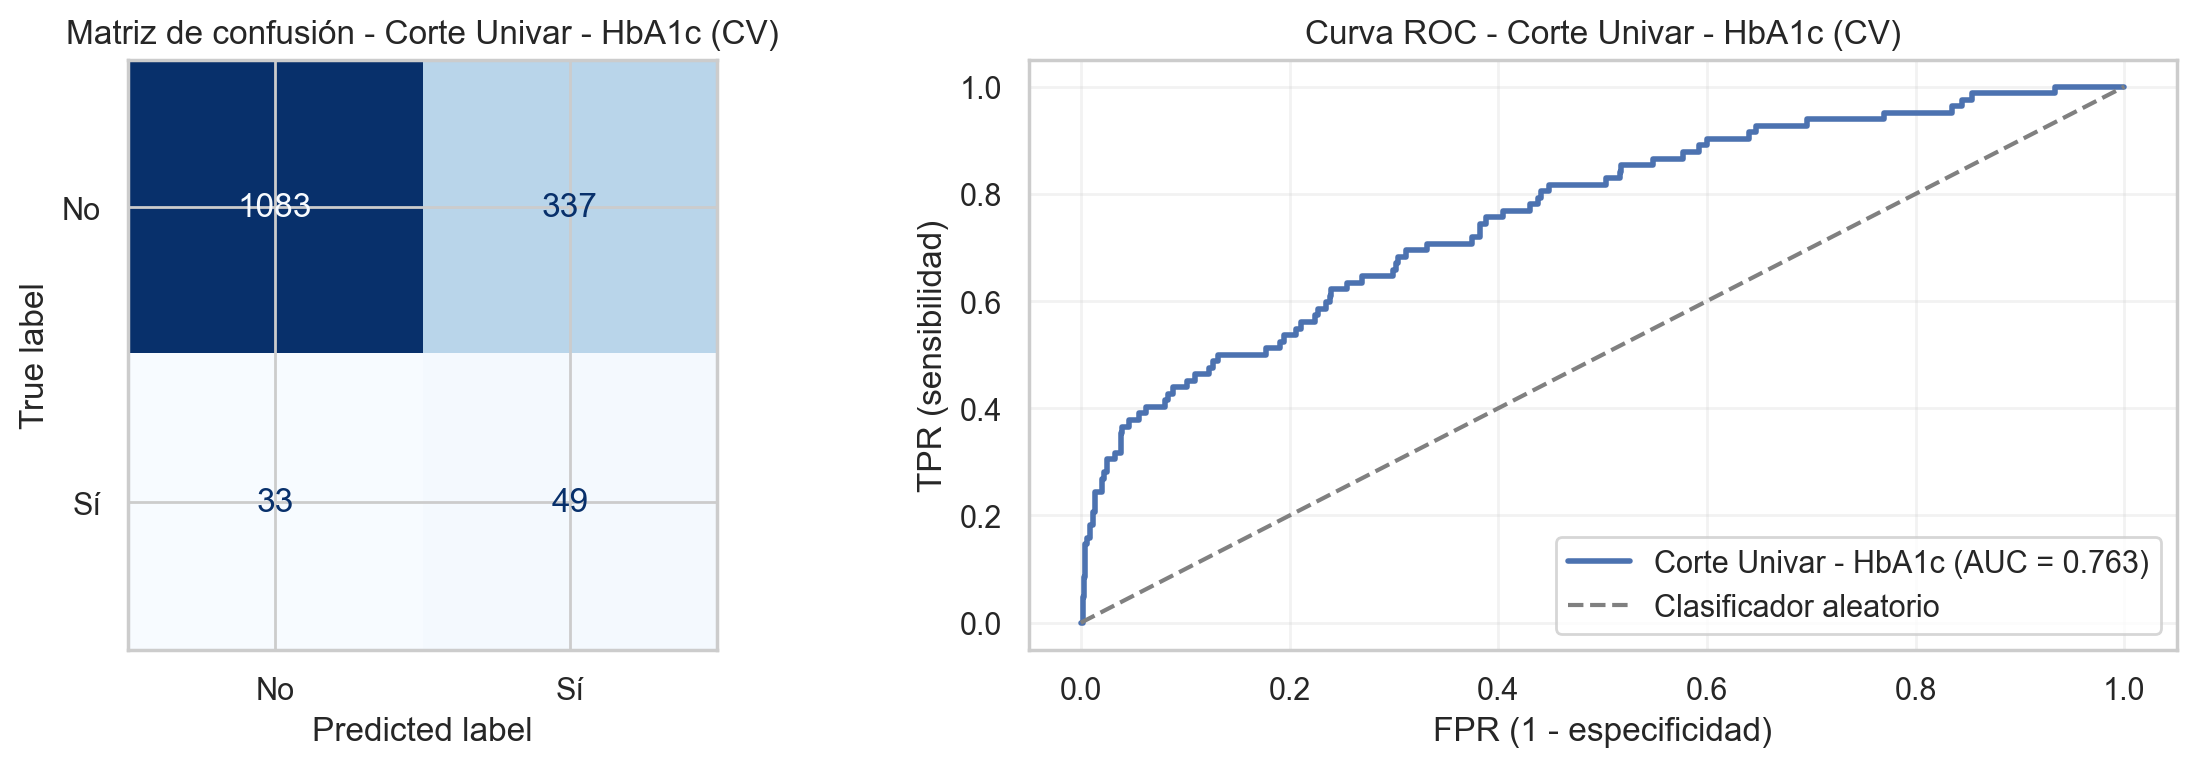


Top-5 cortes para HbA1c:


,threshold,roc_auc_cv,pr_auc_cv,f1_cv
0,5.6,0.7646,0.3160,0.2055
1,5.5,0.7637,0.3174,0.2107
2,5.4,0.7611,0.2988,0.1996
3,5.7,0.7585,0.3249,0.2154
4,5.3,0.7535,0.3011,0.1933


In [158]:
# Celda 46 — HbA1c
print("\n=== Buscando cortes univariados para: 1T hemoglobina glicada ===")

pipe_hba1c = Pipeline([
    ("binar", ThresholdBinarizer(col="1T hemoglobina glicada", drop_original=True)),
    ("prep", preprocesador_base_dinamico(escalar_numericas=False)),
    ("clf", LogisticRegression(max_iter=5000, class_weight="balanced", solver="liblinear"))
])

param_grid_hba1c = {"binar__threshold": candidatos_univariados["1T hemoglobina glicada"]}

grid_hba1c = GridSearchCV(
    estimator=pipe_hba1c,
    param_grid=param_grid_hba1c,
    scoring=scoring_grid,
    refit="roc_auc",
    cv=cv_grid,
    n_jobs=-1,
    verbose=0
)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    grid_hba1c.fit(X_train, y_train)

registrar_resultados("Corte Univar - HbA1c", grid_hba1c, dibujar=True)

idxs = np.argsort(grid_hba1c.cv_results_["mean_test_roc_auc"])[::-1][:5]
top_hba1c = pd.DataFrame({
    "threshold": [grid_hba1c.cv_results_["param_binar__threshold"][i] for i in idxs],
    "roc_auc_cv": [grid_hba1c.cv_results_["mean_test_roc_auc"][i] for i in idxs],
    "pr_auc_cv": [grid_hba1c.cv_results_["mean_test_pr_auc"][i] for i in idxs],
    "f1_cv": [grid_hba1c.cv_results_["mean_test_f1"][i] for i in idxs],
})
print("\nTop-5 cortes para HbA1c:")
display(top_hba1c.round(4))


=== Buscando cortes univariados para: 1t glucosa ===
Corte Univar - Glucosa 1T mejor configuración: {'binar__threshold': 82.0}
Corte Univar - Glucosa 1T ROC-AUC (CV): 0.7466 ± 0.0471


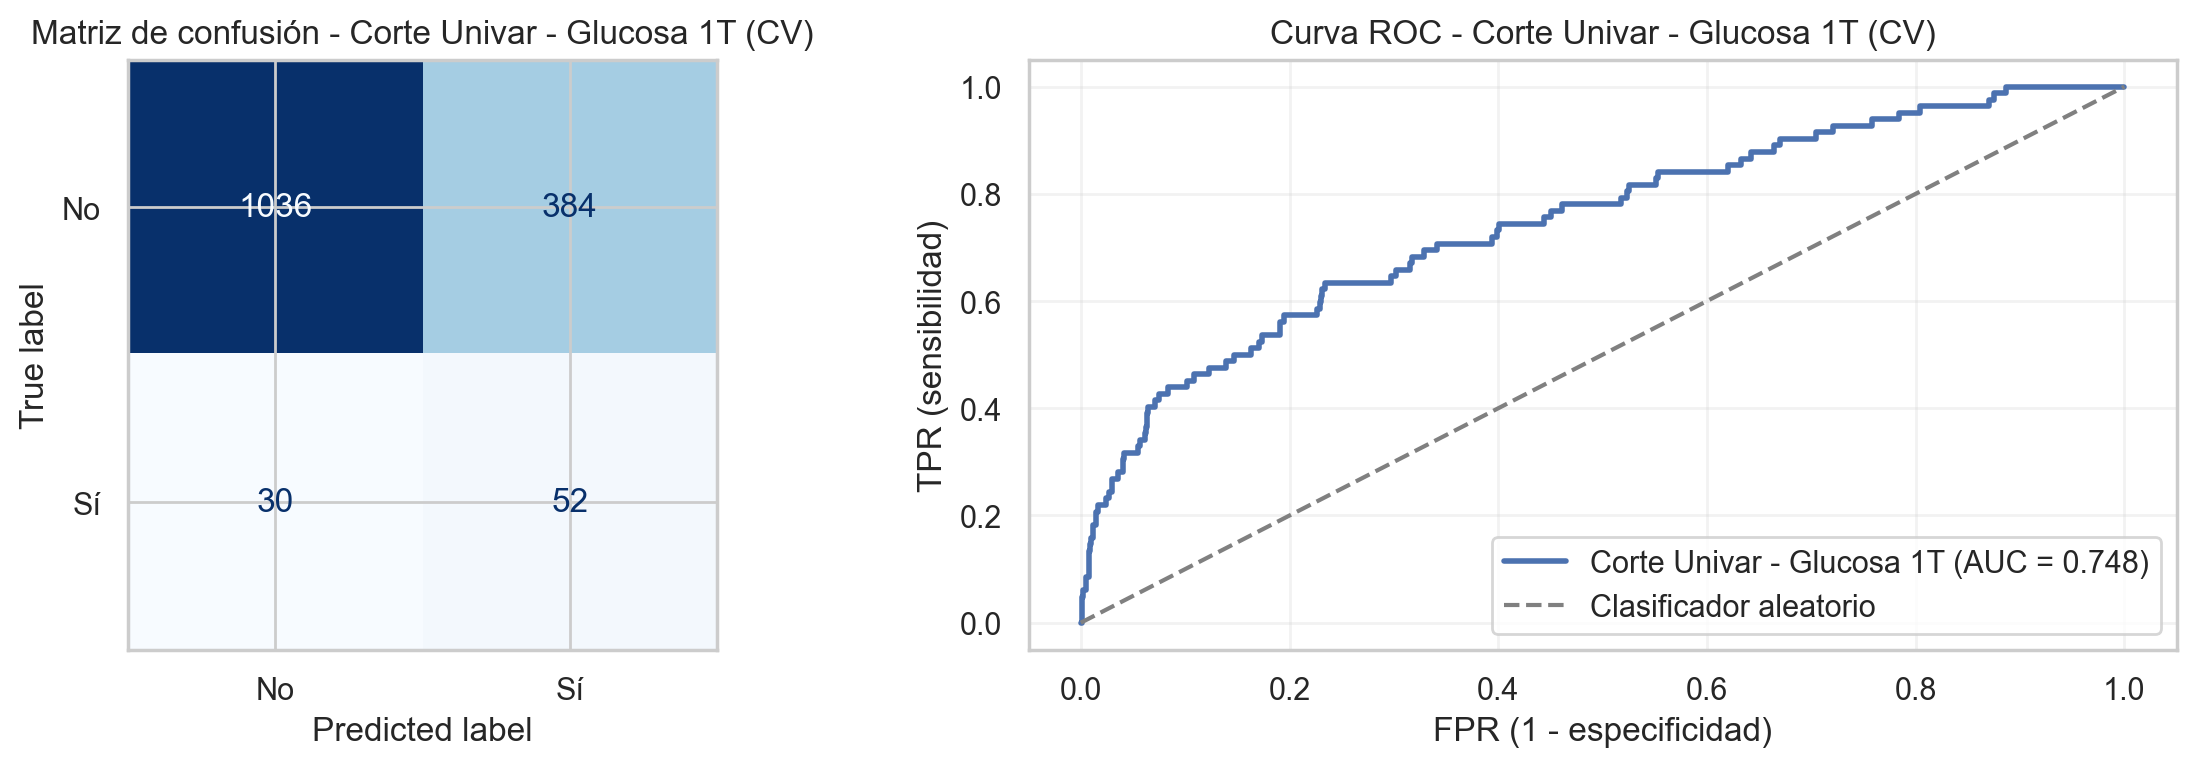


Top-5 cortes para Glucosa 1T:


,threshold,roc_auc_cv,pr_auc_cv,f1_cv
0,82.0,0.7466,0.2770,0.2003
1,84.0,0.7399,0.2748,0.2018
2,89.0,0.7390,0.2805,0.1986
3,100.0,0.7390,0.2933,0.2018
4,74.0,0.7357,0.2603,0.1861


In [159]:
# Celda 47 — Glucosa
print("\n=== Buscando cortes univariados para: 1t glucosa ===")

pipe_gluc = Pipeline([
    ("binar", ThresholdBinarizer(col="1t glucosa", drop_original=True)),
    ("prep", preprocesador_base_dinamico(escalar_numericas=False)),
    ("clf", LogisticRegression(max_iter=5000, class_weight="balanced", solver="liblinear"))
])

param_grid_gluc = {"binar__threshold": candidatos_univariados["1t glucosa"]}

grid_gluc = GridSearchCV(
    estimator=pipe_gluc,
    param_grid=param_grid_gluc,
    scoring=scoring_grid,
    refit="roc_auc",
    cv=cv_grid,
    n_jobs=-1,
    verbose=0
)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    grid_gluc.fit(X_train, y_train)

registrar_resultados("Corte Univar - Glucosa 1T", grid_gluc, dibujar=True)

idxs = np.argsort(grid_gluc.cv_results_["mean_test_roc_auc"])[::-1][:5]
top_gluc = pd.DataFrame({
    "threshold": [grid_gluc.cv_results_["param_binar__threshold"][i] for i in idxs],
    "roc_auc_cv": [grid_gluc.cv_results_["mean_test_roc_auc"][i] for i in idxs],
    "pr_auc_cv": [grid_gluc.cv_results_["mean_test_pr_auc"][i] for i in idxs],
    "f1_cv": [grid_gluc.cv_results_["mean_test_f1"][i] for i in idxs],
})
print("\nTop-5 cortes para Glucosa 1T:")
display(top_gluc.round(4))

In [160]:
print("\n" + "=" * 85)
print("RESUMEN FINAL: TOP-3 CANDIDATOS POR VARIABLE")
print("=" * 85)

summary_data = []
for var, top_df in [
    ("bmi", top_bmi),
    ("edad", top_edad),
    ("1T hemoglobina glicada", top_hba1c),
    ("1t glucosa", top_gluc),
]:
    for i, row in top_df.head(3).iterrows():
        summary_data.append({
            "variable": var,
            "rank": i + 1,
            "threshold": row["threshold"],
            "roc_auc_cv": row["roc_auc_cv"],
            "pr_auc_cv": row["pr_auc_cv"],
            "f1_cv": row["f1_cv"],
        })

df_summary = pd.DataFrame(summary_data)
display(df_summary.round(4))

# Opcional: guardar
df_summary.to_csv("top_cortes_univariados_final.csv", index=False)
print("\nGuardado en: top_cortes_univariados_final.csv")


RESUMEN FINAL: TOP-3 CANDIDATOS POR VARIABLE


,variable,rank,threshold,roc_auc_cv,pr_auc_cv,f1_cv
0,bmi,1,24.224,0.7675,0.3114,0.1997
1,bmi,2,30.000,0.7610,0.3097,0.1983
2,bmi,3,29.988,0.7604,0.3101,0.1993
3,edad,1,29.000,0.7587,0.3082,0.2085
4,edad,2,37.000,0.7576,0.2992,0.2027
5,edad,3,38.000,0.7572,0.2904,0.2024
6,1T hemoglobina glicada,1,5.600,0.7646,0.3160,0.2055
7,1T hemoglobina glicada,2,5.500,0.7637,0.3174,0.2107
8,1T hemoglobina glicada,3,5.400,0.7611,0.2988,0.1996
9,1t glucosa,1,82.000,0.7466,0.2770,0.2003



Guardado en: top_cortes_univariados_final.csv


In [161]:
# Fijado manual de hba1c a 5.5

print("\n=== REFINAMIENTO FINO DE CORTES UNIVARIADOS (SOLO CV) ===\n")

# Mejores univariados
best_bmi = top_bmi.iloc[0]["threshold"]
best_edad = top_edad.iloc[0]["threshold"]
best_gluc = top_gluc.iloc[0]["threshold"]

print("Mejores univariados (base para refinamiento):")
print(f"  bmi: {best_bmi}")
print(f"  edad: {best_edad}")
print(f"  gluc: {best_gluc}")

# Grid fino alrededor de cada valor
def gen_fine_grid(valor, margen_pct=20, n_puntos=30, round_dec=2):
    margen = valor * (margen_pct / 100.0)
    paso = margen / (n_puntos // 2)
    return sorted([round(valor - margen + i * paso, round_dec) for i in range(n_puntos)])

fine_bmi = gen_fine_grid(best_bmi, margen_pct=20, n_puntos=20)
fine_edad = gen_fine_grid(best_edad, margen_pct=20, n_puntos=15, round_dec=0)
fine_gluc = gen_fine_grid(best_gluc, margen_pct=12, n_puntos=17, round_dec=0)

print("\nGrids finos:")
print(f"  bmi: {fine_bmi}")
print(f"  edad: {fine_edad}")
print(f"  gluc: {fine_gluc}")

# Refinar cada variable y devolver top-5 solo con CV
def refine_univariate_top5(var, fine_grid):
    pipe = Pipeline([
        ("binar", ThresholdBinarizer(col=var, drop_original=True)),
        ("prep", preprocesador_base_dinamico(escalar_numericas=False)),
        ("clf", LogisticRegression(max_iter=5000, class_weight="balanced", solver="liblinear"))
    ])

    param_grid = {"binar__threshold": fine_grid}
    grid = GridSearchCV(
        pipe,
        param_grid,
        scoring=scoring_grid,
        refit="roc_auc",
        cv=cv_grid,
        n_jobs=-1,
        verbose=0
    )

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        grid.fit(X_train, y_train)

    idxs = np.argsort(grid.cv_results_["mean_test_roc_auc"])[::-1][:5]

    rows = []
    for idx in idxs:
        rows.append({
            "threshold": grid.cv_results_["param_binar__threshold"][idx],
            "roc_auc_cv": grid.cv_results_["mean_test_roc_auc"][idx],
            "pr_auc_cv": grid.cv_results_["mean_test_pr_auc"][idx],
            "f1_cv": grid.cv_results_["mean_test_f1"][idx],
        })

    return pd.DataFrame(rows)

print("\nRefinando y extrayendo Top-5 (solo CV)...\n")

print("BMI:")
refined_bmi_top5 = refine_univariate_top5("bmi", fine_bmi)
display(refined_bmi_top5.round(4))
refined_bmi = refined_bmi_top5.iloc[0]["threshold"]

print("\nEdad:")
refined_edad_top5 = refine_univariate_top5("edad", fine_edad)
display(refined_edad_top5.round(4))
refined_edad = refined_edad_top5.iloc[0]["threshold"]

print("\nGlucosa:")
refined_gluc_top5 = refine_univariate_top5("1t glucosa", fine_gluc)
display(refined_gluc_top5.round(4))
refined_gluc = refined_gluc_top5.iloc[0]["threshold"]

print("\n" + "=" * 80)
print("RESUMEN: MEJOR DE CADA VARIABLE (Top-1 del refinamiento)")
print("=" * 80)
print(f"  bmi: {refined_bmi} (CV={refined_bmi_top5.iloc[0]['roc_auc_cv']:.4f})")
print(f"  edad: {refined_edad} (CV={refined_edad_top5.iloc[0]['roc_auc_cv']:.4f})")
print(f"  gluc: {refined_gluc} (CV={refined_gluc_top5.iloc[0]['roc_auc_cv']:.4f})")
print("=" * 80)


=== REFINAMIENTO FINO DE CORTES UNIVARIADOS (SOLO CV) ===

Mejores univariados (base para refinamiento):
  bmi: 24.224
  edad: 29.0
  gluc: 82.0

Grids finos:
  bmi: [19.38, 19.86, 20.35, 20.83, 21.32, 21.8, 22.29, 22.77, 23.26, 23.74, 24.22, 24.71, 25.19, 25.68, 26.16, 26.65, 27.13, 27.62, 28.1, 28.58]
  edad: [23.0, 24.0, 25.0, 26.0, 27.0, 27.0, 28.0, 29.0, 30.0, 31.0, 31.0, 32.0, 33.0, 34.0, 35.0]
  gluc: [72.0, 73.0, 75.0, 76.0, 77.0, 78.0, 80.0, 81.0, 82.0, 83.0, 84.0, 86.0, 87.0, 88.0, 89.0, 91.0, 92.0]

Refinando y extrayendo Top-5 (solo CV)...

BMI:


,threshold,roc_auc_cv,pr_auc_cv,f1_cv
0,24.71,0.7695,0.3142,0.1995
1,25.19,0.7672,0.3161,0.2122
2,24.22,0.7669,0.3110,0.2002
3,23.74,0.7636,0.3092,0.1982
4,23.26,0.7611,0.3106,0.2017



Edad:


,threshold,roc_auc_cv,pr_auc_cv,f1_cv
0,28.0,0.7648,0.3131,0.2084
1,26.0,0.7608,0.3035,0.2057
2,29.0,0.7587,0.3082,0.2085
3,27.0,0.7585,0.3056,0.2088
4,27.0,0.7585,0.3056,0.2088



Glucosa:


,threshold,roc_auc_cv,pr_auc_cv,f1_cv
0,87.0,0.7579,0.2881,0.2254
1,81.0,0.7529,0.2780,0.1964
2,88.0,0.7509,0.2935,0.2256
3,73.0,0.7489,0.2605,0.1891
4,86.0,0.7486,0.2868,0.1989



RESUMEN: MEJOR DE CADA VARIABLE (Top-1 del refinamiento)
  bmi: 24.71 (CV=0.7695)
  edad: 28.0 (CV=0.7648)
  gluc: 87.0 (CV=0.7579)


In [162]:
refined_bmi = 25.19
refined_edad = 28.0  
refined_hba1c = 5.5  
refined_gluc = 87  

cuts = {
    "bmi": refined_bmi,
    "edad": refined_edad,
    "1T hemoglobina glicada": refined_hba1c,
    "1t glucosa": refined_gluc,
}

class MultiThresholdBinarizer(BaseEstimator, TransformerMixin):
    def __init__(self, cuts_map=None):
        self.cuts_map = cuts_map or {}

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X2 = X.copy()
        for col, thr in self.cuts_map.items():
            if col in X2.columns and thr is not None:
                vals = pd.to_numeric(X2[col], errors="coerce")
                X2[col] = (vals >= float(thr)).astype(int).fillna(0)
        return X2

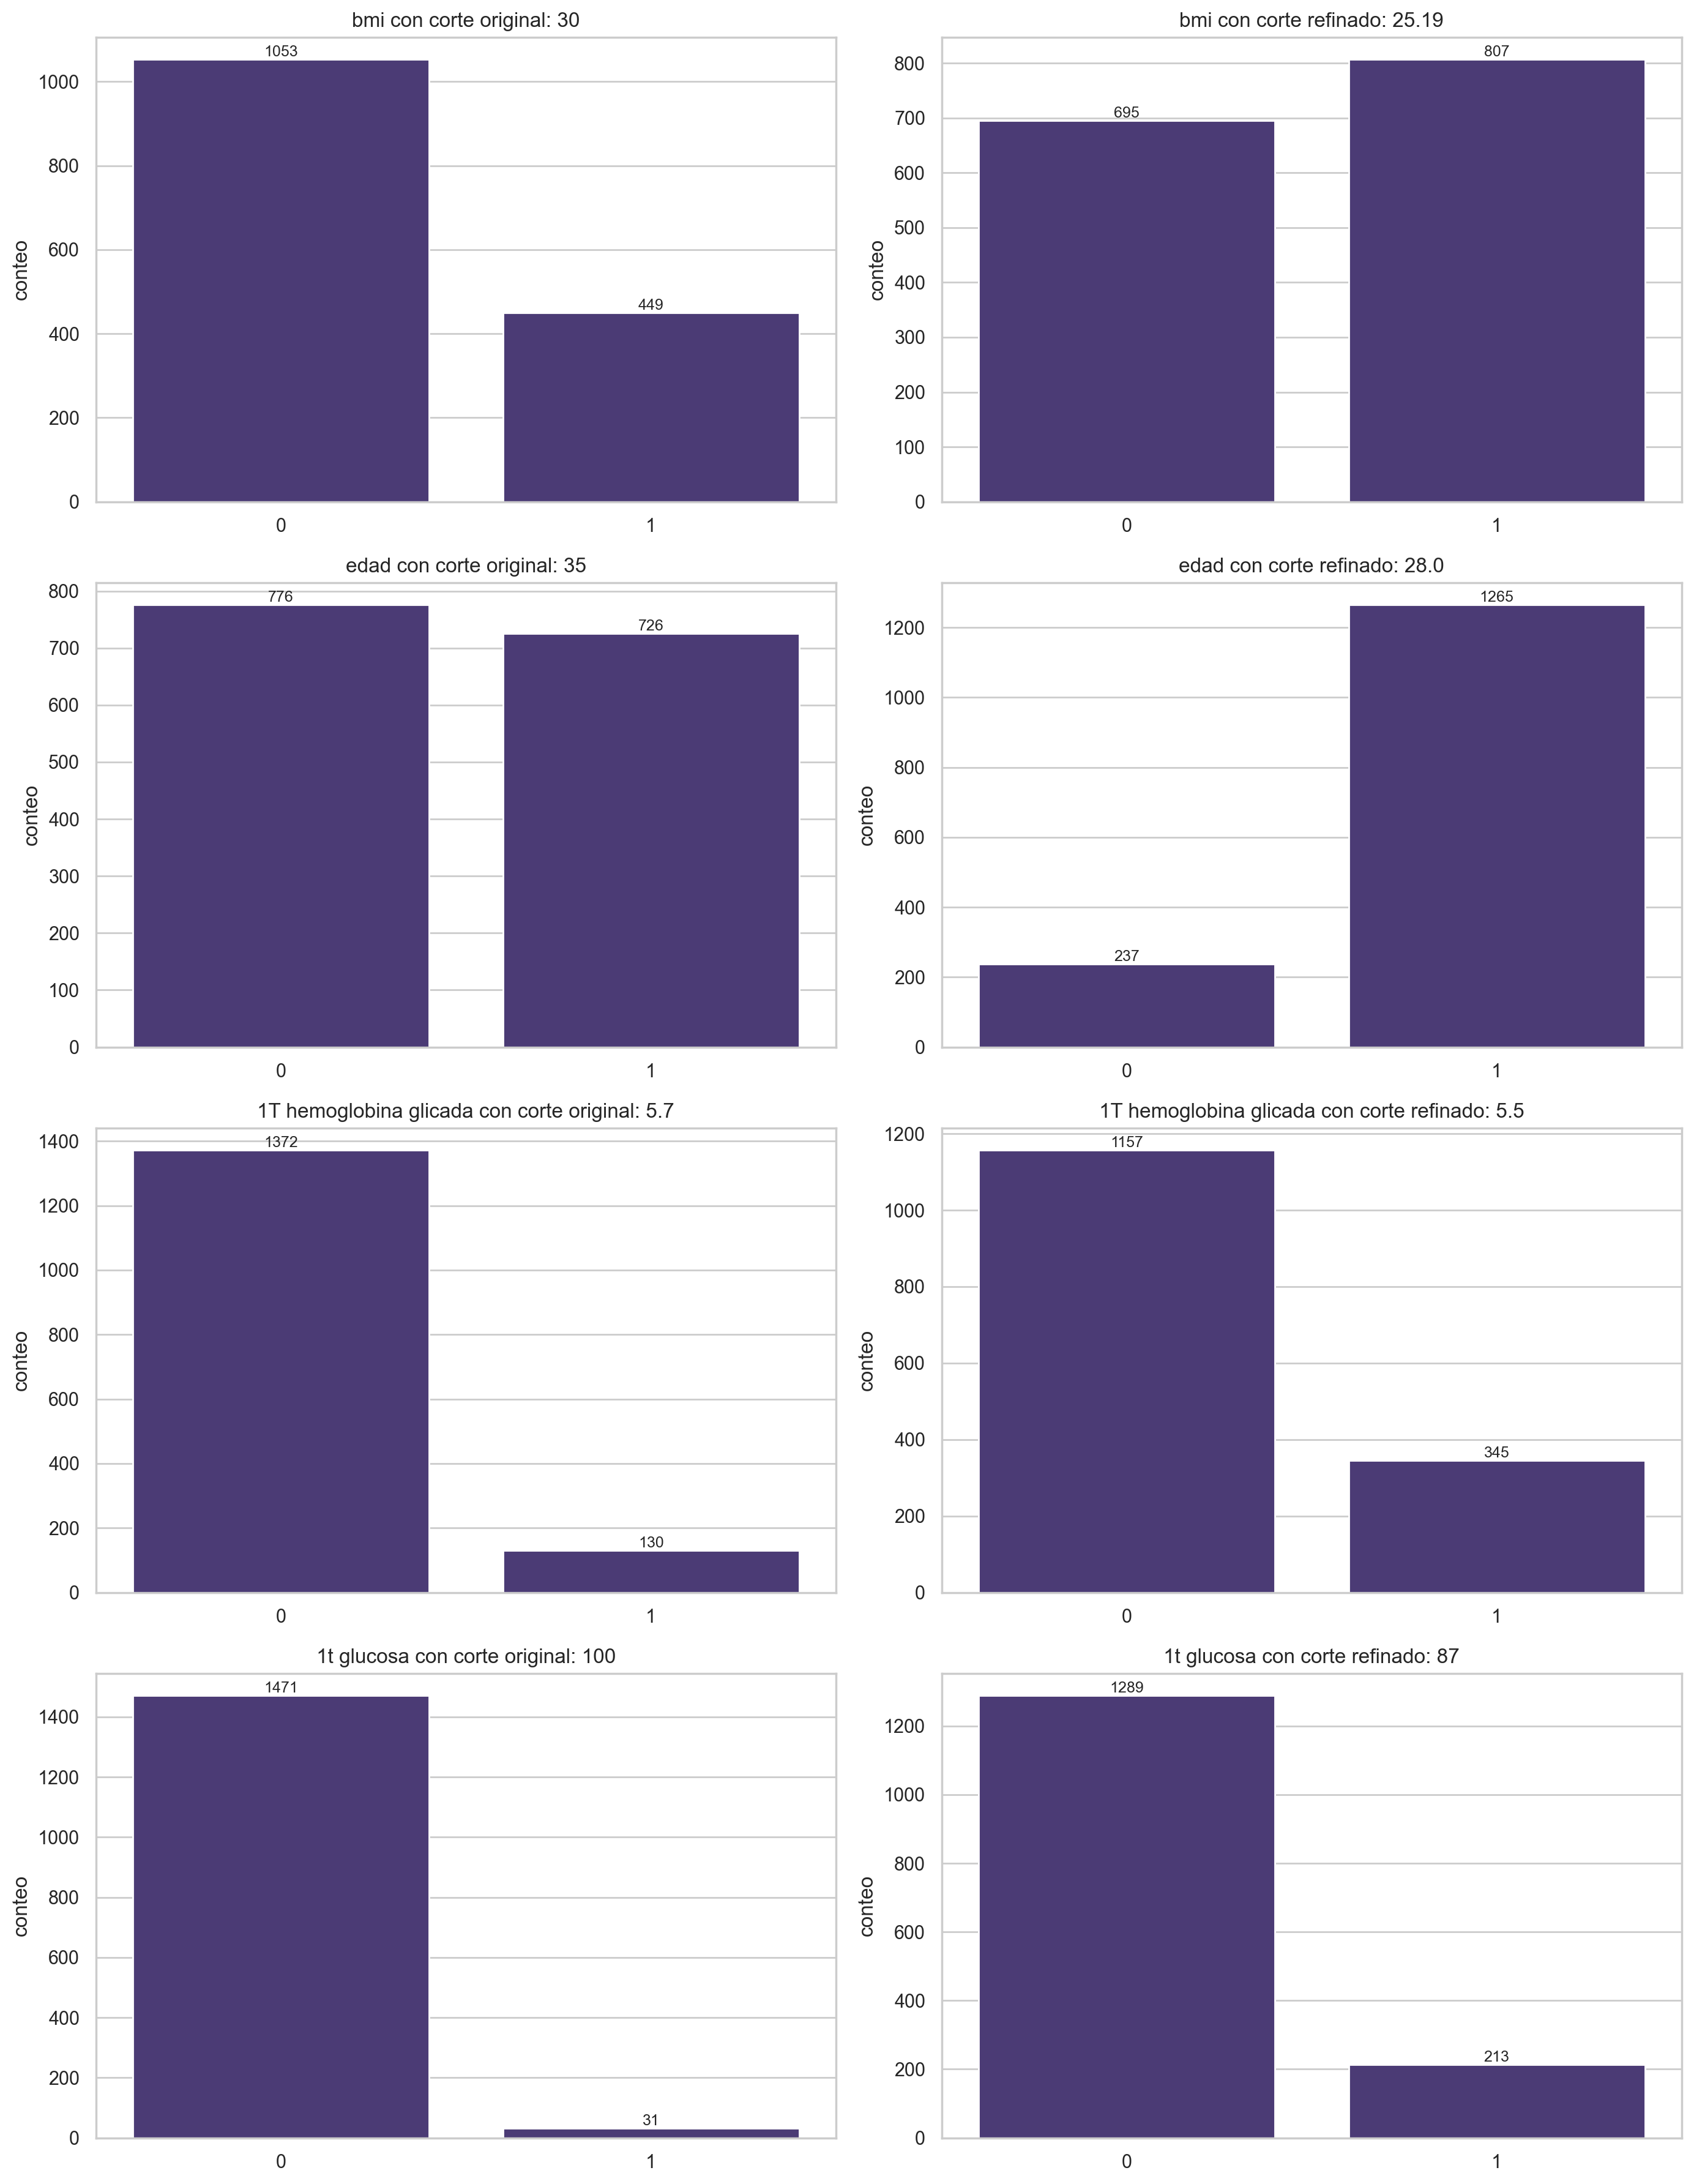

In [163]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

cuts_original = {
    "bmi": 30,
    "edad": 35,
    "1T hemoglobina glicada": 5.7,
    "1t glucosa": 100
}

cuts_refined = {
    "bmi": refined_bmi,
    "edad": refined_edad,
    "1T hemoglobina glicada": refined_hba1c,
    "1t glucosa": refined_gluc
}

variables_plot = [
    "bmi",
    "edad",
    "1T hemoglobina glicada",
    "1t glucosa"
]

# Usa X_train si existe; si no, intenta con df_final_cont
base_df = X_train.copy() if "X_train" in globals() else df_final_cont.drop(columns=["GDM1"]).copy()

# Nos quedamos solo con variables disponibles y con cortes definidos
variables_plot = [v for v in variables_plot if v in base_df.columns and v in cuts_original and v in cuts_refined]

df_original = base_df.copy()
df_refined = base_df.copy()

# Aplicar cortes originales
for col, thr in cuts_original.items():
    if col in df_original.columns:
        vals = pd.to_numeric(df_original[col], errors="coerce")
        df_original[col] = (vals >= float(thr)).astype(int).fillna(0)

# Aplicar cortes refinados
for col, thr in cuts_refined.items():
    if col in df_refined.columns:
        vals = pd.to_numeric(df_refined[col], errors="coerce")
        df_refined[col] = (vals >= float(thr)).astype(int).fillna(0)

n = len(variables_plot)
fig, axes = plt.subplots(n, 2, figsize=(14, 4.5 * n))

if n == 1:
    axes = np.array([axes])

for i, col in enumerate(variables_plot):
    thr_orig = cuts_original[col]
    thr_ref = cuts_refined[col]

    # Izquierda: corte original
    ax_left = axes[i, 0]
    sns.countplot(data=df_original, x=col, ax=ax_left, color=sns.color_palette("viridis")[0])
    ax_left.set_title(f"{col} con corte original: {thr_orig}")
    ax_left.set_xlabel("")
    ax_left.set_ylabel("conteo")
    ax_left.tick_params(axis="x", rotation=0)

    for p in ax_left.patches:
        height = p.get_height()
        ax_left.annotate(
            f"{int(height)}",
            (p.get_x() + p.get_width() / 2, height),
            ha="center",
            va="bottom",
            fontsize=9
        )

    # Derecha: corte refinado
    ax_right = axes[i, 1]
    sns.countplot(data=df_refined, x=col, ax=ax_right, color=sns.color_palette("viridis")[0])
    ax_right.set_title(f"{col} con corte refinado: {thr_ref}")
    ax_right.set_xlabel("")
    ax_right.set_ylabel("conteo")
    ax_right.tick_params(axis="x", rotation=0)

    for p in ax_right.patches:
        height = p.get_height()
        ax_right.annotate(
            f"{int(height)}",
            (p.get_x() + p.get_width() / 2, height),
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout()
plt.show()

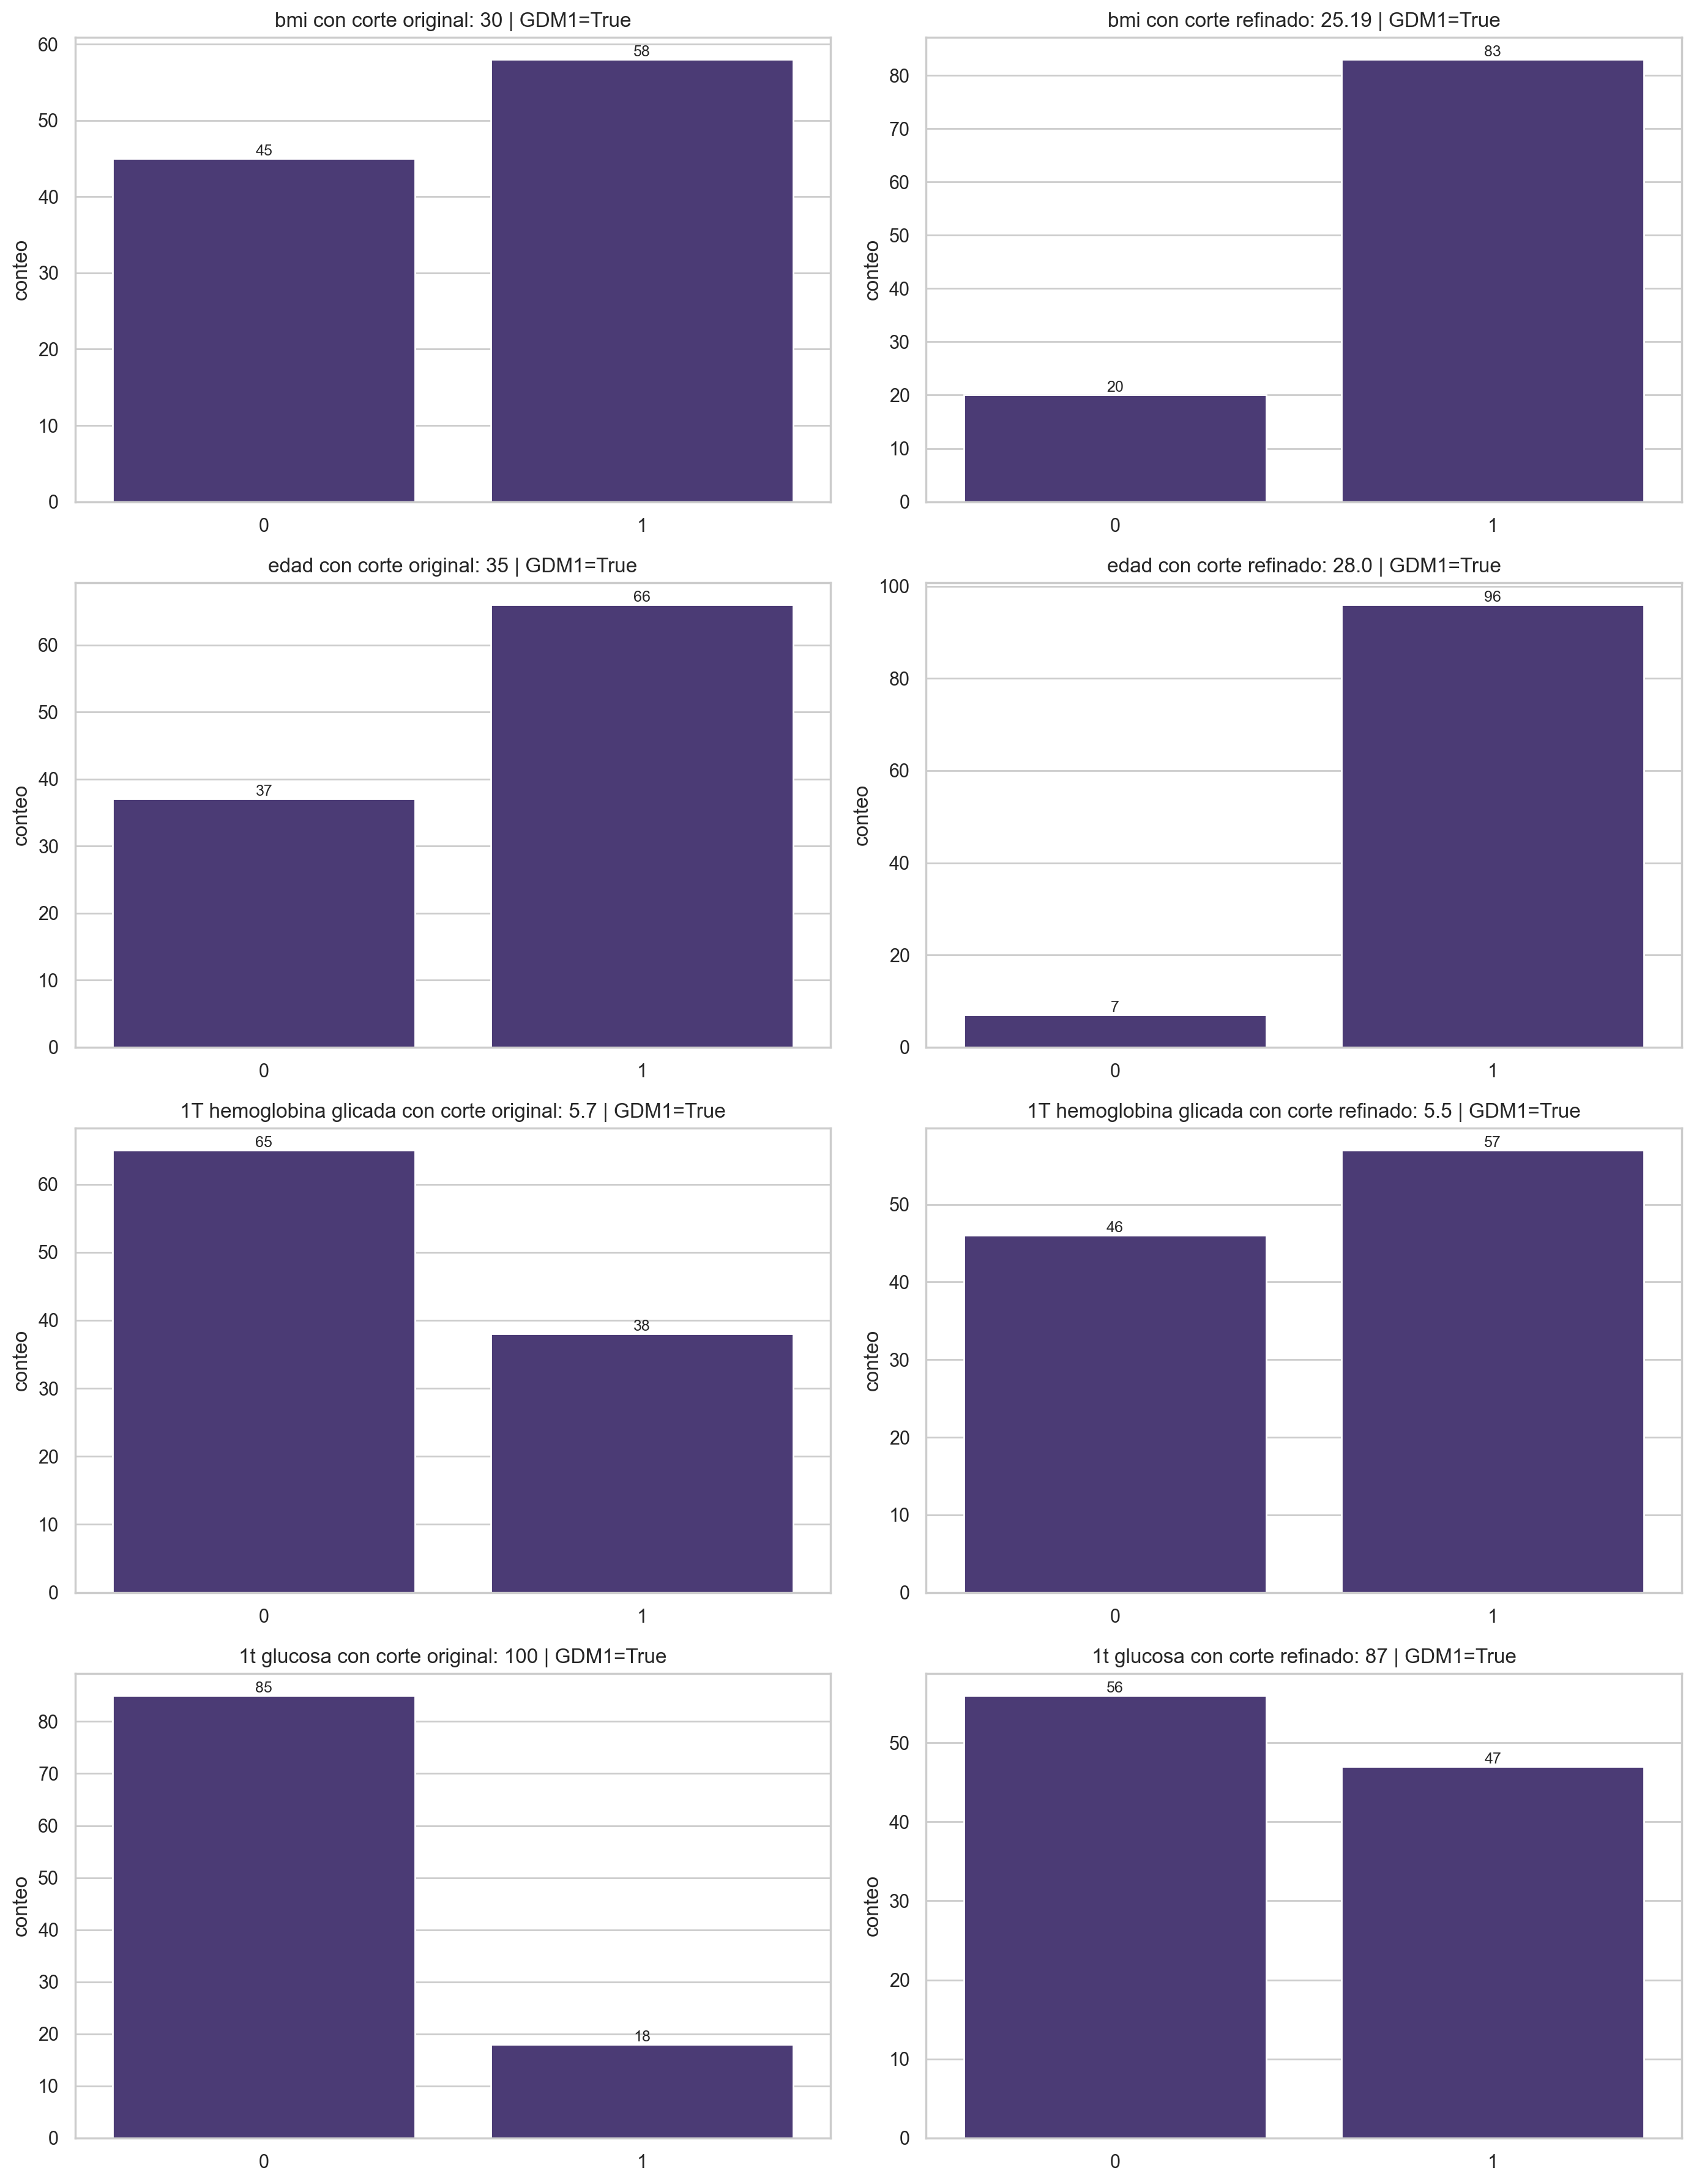

Total de pacientes con GDM1=True: 103


In [164]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

cuts_original = {
    "bmi": 30,
    "edad": 35,
    "1T hemoglobina glicada": 5.7,
    "1t glucosa": 100
}

cuts_refined = {
    "bmi": refined_bmi,
    "edad": refined_edad,
    "1T hemoglobina glicada": refined_hba1c,
    "1t glucosa": refined_gluc
}

variables_plot = [
    "bmi",
    "edad",
    "1T hemoglobina glicada",
    "1t glucosa"
]

# Solo pacientes con GDM1=True
df_pos = df_sin_analisis[df_sin_analisis["GDM1"] == True].copy()
base_df = df_pos.drop(columns=["GDM1"]).copy()

variables_plot = [
    v for v in variables_plot
    if v in base_df.columns and v in cuts_original and v in cuts_refined
]

df_original = base_df.copy()
df_refined = base_df.copy()

# Aplicar cortes originales
for col, thr in cuts_original.items():
    if col in df_original.columns:
        vals = pd.to_numeric(df_original[col], errors="coerce")
        df_original[col] = (vals >= float(thr)).astype(int).fillna(0)

# Aplicar cortes refinados
for col, thr in cuts_refined.items():
    if col in df_refined.columns:
        vals = pd.to_numeric(df_refined[col], errors="coerce")
        df_refined[col] = (vals >= float(thr)).astype(int).fillna(0)

n = len(variables_plot)
fig, axes = plt.subplots(n, 2, figsize=(14, 4.5 * n))

if n == 1:
    axes = np.array([axes])

for i, col in enumerate(variables_plot):
    thr_orig = cuts_original[col]
    thr_ref = cuts_refined[col]

    # Izquierda: corte original, solo GDM1=True
    ax_left = axes[i, 0]
    sns.countplot(data=df_original, x=col, ax=ax_left, color=sns.color_palette("viridis")[0])
    ax_left.set_title(f"{col} con corte original: {thr_orig} | GDM1=True")
    ax_left.set_xlabel("")
    ax_left.set_ylabel("conteo")
    ax_left.tick_params(axis="x", rotation=0)

    for p in ax_left.patches:
        height = p.get_height()
        ax_left.annotate(
            f"{int(height)}",
            (p.get_x() + p.get_width() / 2, height),
            ha="center",
            va="bottom",
            fontsize=9
        )

    # Derecha: corte refinado, solo GDM1=True
    ax_right = axes[i, 1]
    sns.countplot(data=df_refined, x=col, ax=ax_right, color=sns.color_palette("viridis")[0])
    ax_right.set_title(f"{col} con corte refinado: {thr_ref} | GDM1=True")
    ax_right.set_xlabel("")
    ax_right.set_ylabel("conteo")
    ax_right.tick_params(axis="x", rotation=0)

    for p in ax_right.patches:
        height = p.get_height()
        ax_right.annotate(
            f"{int(height)}",
            (p.get_x() + p.get_width() / 2, height),
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout()
plt.show()

print(f"Total de pacientes con GDM1=True: {len(df_pos)}")

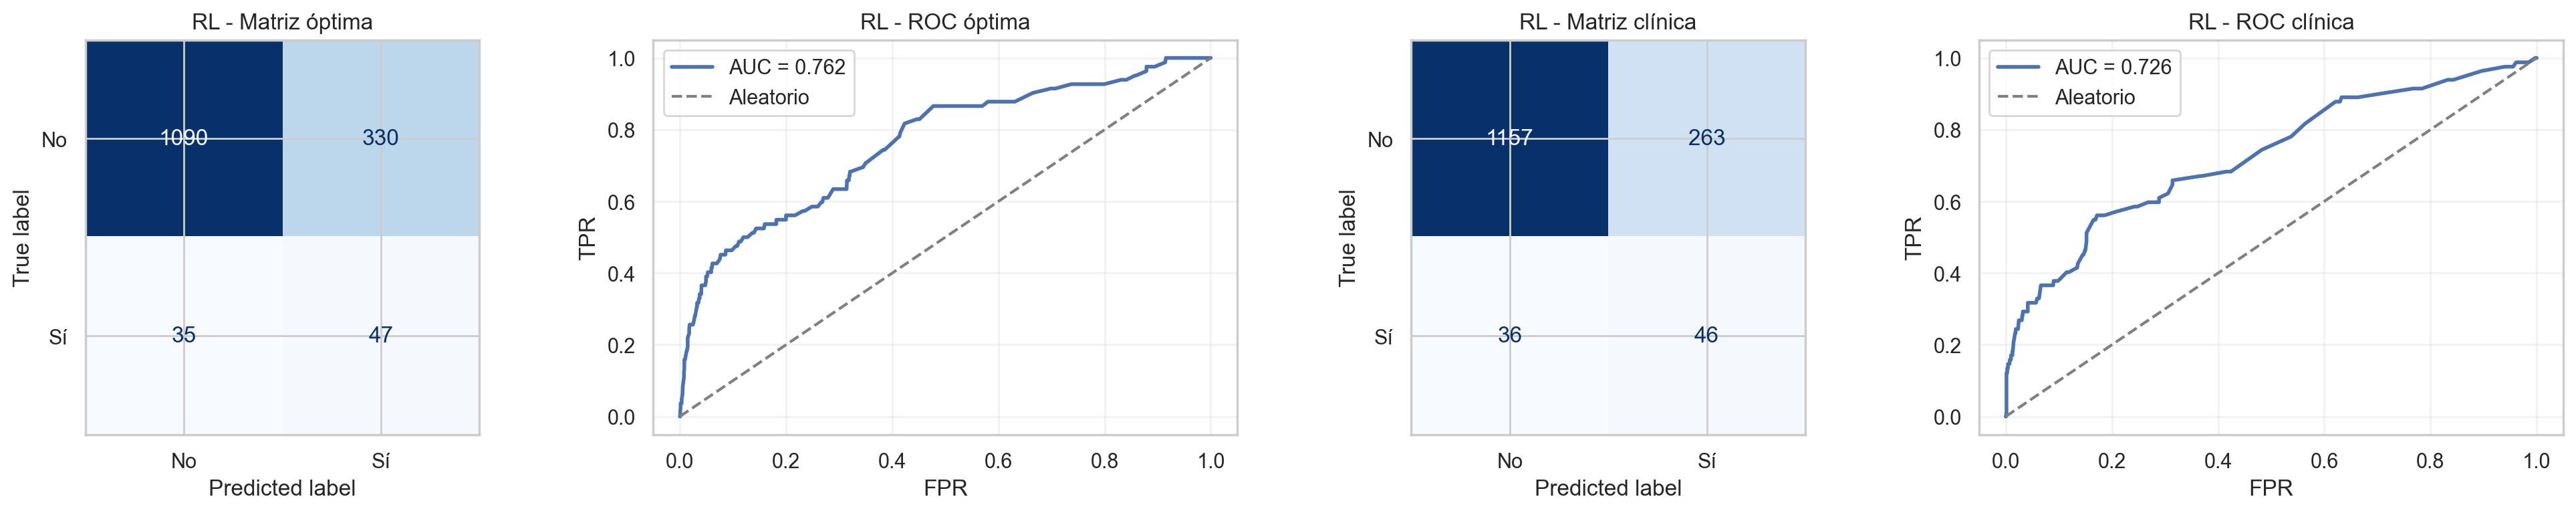


MÉTRICAS - REGRESIÓN LOGÍSTICA (RL)

CORTES ÓPTIMOS:
  ROC-AUC: 0.7680
  PR-AUC:  0.2875
  F1:      0.2135

CORTES CLÍNICOS:
  ROC-AUC: 0.7375
  PR-AUC:  0.2906
  F1:      0.2326


In [165]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RepeatedStratifiedKFold, StratifiedKFold, cross_validate, cross_val_predict
from sklearn.metrics import roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve

# Cortes clínicos y cortes óptimos
cuts_clinicos = {
    "bmi": 30,
    "edad": 35,
    "1T hemoglobina glicada": 5.7,
    "1t glucosa": 100
}

cuts_optimos = {
    "bmi": refined_bmi,
    "edad": refined_edad,
    "1T hemoglobina glicada": refined_hba1c,
    "1t glucosa": refined_gluc
}

# Asegura que existe el builder de RL
if "build_pipeline_lr" not in globals():
    raise NameError("Falta ejecutar antes la celda que define build_pipeline_lr")

class MultiThresholdBinarizer(BaseEstimator, TransformerMixin):
    def __init__(self, cuts_map=None):
        self.cuts_map = cuts_map or {}

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X2 = X.copy()
        for col, thr in self.cuts_map.items():
            if col in X2.columns and thr is not None:
                vals = pd.to_numeric(X2[col], errors="coerce")
                X2[col] = (vals >= float(thr)).astype(int).fillna(0)
        return X2

def construir_pipe_fair(cuts_map, builder_func, X_df):
    return Pipeline([
        ("binar", MultiThresholdBinarizer(cuts_map=cuts_map)),
        ("model", builder_func(X_df))
    ])

# Solo RL
builder_func = build_pipeline_lr
nombre = "RL"

# Validación para tabla final
cv_table = RepeatedStratifiedKFold(n_splits=5, n_repeats=20, random_state=123)
scoring_table = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "f1": "f1"
}

# Validación para figura
cv_plot = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipe_clinico = construir_pipe_fair(cuts_clinicos, builder_func, X_train)
pipe_optimo = construir_pipe_fair(cuts_optimos, builder_func, X_train)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    scores_cli = cross_validate(
        pipe_clinico,
        X_train,
        y_train,
        cv=cv_table,
        scoring=scoring_table,
        n_jobs=-1
    )
    scores_opt = cross_validate(
        pipe_optimo,
        X_train,
        y_train,
        cv=cv_table,
        scoring=scoring_table,
        n_jobs=-1
    )

resultados_clinicos = {
    "roc_auc": float(np.mean(scores_cli["test_roc_auc"])),
    "pr_auc": float(np.mean(scores_cli["test_pr_auc"])),
    "f1": float(np.mean(scores_cli["test_f1"]))
}

resultados_optimos = {
    "roc_auc": float(np.mean(scores_opt["test_roc_auc"])),
    "pr_auc": float(np.mean(scores_opt["test_pr_auc"])),
    "f1": float(np.mean(scores_opt["test_f1"]))
}

# Predicciones para la figura
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    y_pred_opt = cross_val_predict(pipe_optimo, X_train, y_train, cv=cv_plot)
    y_proba_opt = cross_val_predict(pipe_optimo, X_train, y_train, cv=cv_plot, method="predict_proba")[:, 1]
    y_pred_cli = cross_val_predict(pipe_clinico, X_train, y_train, cv=cv_plot)
    y_proba_cli = cross_val_predict(pipe_clinico, X_train, y_train, cv=cv_plot, method="predict_proba")[:, 1]

auc_opt = roc_auc_score(y_train, y_proba_opt)
auc_cli = roc_auc_score(y_train, y_proba_cli)

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

cm_opt = confusion_matrix(y_train, y_pred_opt)
disp_opt = ConfusionMatrixDisplay(confusion_matrix=cm_opt, display_labels=["No", "Sí"])
disp_opt.plot(ax=axes[0], cmap="Blues", colorbar=False, values_format="d")
axes[0].set_title("RL - Matriz óptima")

fpr_opt, tpr_opt, _ = roc_curve(y_train, y_proba_opt)
axes[1].plot(fpr_opt, tpr_opt, label=f"AUC = {auc_opt:.3f}", linewidth=2)
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Aleatorio")
axes[1].set_xlabel("FPR")
axes[1].set_ylabel("TPR")
axes[1].set_title("RL - ROC óptima")
axes[1].legend()
axes[1].grid(alpha=0.25)

cm_cli = confusion_matrix(y_train, y_pred_cli)
disp_cli = ConfusionMatrixDisplay(confusion_matrix=cm_cli, display_labels=["No", "Sí"])
disp_cli.plot(ax=axes[2], cmap="Blues", colorbar=False, values_format="d")
axes[2].set_title("RL - Matriz clínica")

fpr_cli, tpr_cli, _ = roc_curve(y_train, y_proba_cli)
axes[3].plot(fpr_cli, tpr_cli, label=f"AUC = {auc_cli:.3f}", linewidth=2)
axes[3].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Aleatorio")
axes[3].set_xlabel("FPR")
axes[3].set_ylabel("TPR")
axes[3].set_title("RL - ROC clínica")
axes[3].legend()
axes[3].grid(alpha=0.25)

plt.tight_layout()
plt.show()

# Print de métricas
print("\n" + "="*60)
print("MÉTRICAS - REGRESIÓN LOGÍSTICA (RL)")
print("="*60)
print("\nCORTES ÓPTIMOS:")
print(f"  ROC-AUC: {resultados_optimos['roc_auc']:.4f}")
print(f"  PR-AUC:  {resultados_optimos['pr_auc']:.4f}")
print(f"  F1:      {resultados_optimos['f1']:.4f}")
print("\nCORTES CLÍNICOS:")
print(f"  ROC-AUC: {resultados_clinicos['roc_auc']:.4f}")
print(f"  PR-AUC:  {resultados_clinicos['pr_auc']:.4f}")
print(f"  F1:      {resultados_clinicos['f1']:.4f}")
print("="*60)

In [166]:
from sklearn.base import BaseEstimator, TransformerMixin

class MultiThresholdBinarizer(BaseEstimator, TransformerMixin):
    def __init__(self, cuts_map=None):
        self.cuts_map = cuts_map  # NO modificar el parámetro aquí

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X2 = X.copy()
        cuts = self.cuts_map or {}  # usar valor por defecto aquí, no en __init__
        for col, thr in cuts.items():
            if col in X2.columns and thr is not None:
                vals = pd.to_numeric(X2[col], errors="coerce")
                X2[col] = (vals >= float(thr)).astype(int).fillna(0)
        return X2

In [167]:
# Generar rejillas amplias de candidatos para cada variable continua
import numpy as np
import pandas as pd

def make_candidates(series, n=200, pct=(1,99), round_dec=None, unique_limit=0):
    vals = pd.to_numeric(series, errors="coerce").dropna().values
    low, high = np.percentile(vals, [pct[0], pct[1]])
    if low == high:
        low = vals.min(); high = vals.max()
    grid = np.linspace(low, high, n)
    if round_dec is not None:
        grid = np.round(grid, round_dec)
    return sorted(np.unique(grid).tolist())

# Lista de variables continuas a ampliar (ajusta si falta/añade más)
vars_cont = ["1t glucosa", "bmi", "1T hemoglobina glicada", "edad"]

# Construir nuevo dict de candidatos con más puntos
new_candidatos = {}
for v in vars_cont:
    if v not in X_train.columns:
        continue
    if v == "edad":
        new_candidatos[v] = make_candidates(X_train[v], n=20, pct=(10,90), round_dec=0)
    elif v == "1t glucosa":
        new_candidatos[v] = make_candidates(X_train[v], n=30, pct=(20,97), round_dec=0)
    elif v == "1T hemoglobina glicada":
        new_candidatos[v] = make_candidates(X_train[v], n=10, pct=(1,99), round_dec=1)
    elif v == "bmi":
        new_candidatos[v] = make_candidates(X_train[v], n=30, pct=(35,80), round_dec=2)

# Reemplazar el objeto en memoria
candidatos_univariados = new_candidatos

# Resumen rápido
for k, v in candidatos_univariados.items():
    print(f"{k:30s} -> {len(v):3d} candidatos, ejemplo: {v[:5]} ... {v[-3:]}")

1t glucosa                     ->  27 candidatos, ejemplo: [71.0, 72.0, 73.0, 74.0, 75.0] ... [95.0, 96.0, 97.0]
bmi                            ->  30 candidatos, ejemplo: [23.59, 23.88, 24.16, 24.45, 24.74] ... [31.36, 31.64, 31.93]
1T hemoglobina glicada         ->  10 candidatos, ejemplo: [4.5, 4.7, 4.9, 5.0, 5.2] ... [5.7, 5.9, 6.1]
edad                           ->  17 candidatos, ejemplo: [25.0, 26.0, 27.0, 28.0, 29.0] ... [39.0, 40.0, 41.0]


In [55]:
# Multivariante (pares) — búsqueda de thresholds para Logistic Regression
# CON reporte del mejor corte por cada par
# MODIFICADO: top_k_per_var ahora elige k candidatos ALEATORIOs (no los k mejores)
import itertools
import copy
import pandas as pd
import numpy as np
import warnings
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Parámetros de control
vars_pool = ["1t glucosa", "bmi", "1T hemoglobina glicada", "edad"]
top_k_per_var = 30  # Ahora: número de candidatos ALEATORIOS por variable
random_seed = 42
max_combinations = None
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring_grid = {"roc_auc": "roc_auc", "pr_auc": "average_precision", "f1": "f1"}

# Base: cortes clínicos
base_cuts = cuts_clinicos.copy() if "cuts_clinicos" in globals() else {}

# Construir candidatos (k aleatorios)
cands_map = {}
rng = np.random.default_rng(random_seed)
for v in vars_pool:
    if v in candidatos_univariados:
        cands = list(candidatos_univariados[v])
        # CAMBIO: elegir k candidatos ALEATORIOs en lugar de los primeros k
        n_choose = min(top_k_per_var, len(cands))
        selected = rng.choice(cands, size=n_choose, replace=False)
        cands_map[v] = selected.tolist()
        print(f"{v}: seleccionados {n_choose} aleatorios de {len(cands)} candidatos")
    else:
        raise KeyError(f"No hay candidatos para {v}")

# Generar pares
pairs = list(itertools.combinations(vars_pool, 2))

results_pairs = []
best_per_pair = {}

for pair in pairs:
    grids = list(itertools.product(*(cands_map[p] for p in pair)))
    if max_combinations and len(grids) > max_combinations:
        rng2 = np.random.default_rng(random_seed)
        grids = rng2.choice(grids, size=max_combinations, replace=False).tolist()

    cuts_maps = []
    for thr_vals in grids:
        cm = copy.deepcopy(base_cuts)
        for v, thr in zip(pair, thr_vals):
            cm[v] = thr
        cuts_maps.append(cm)

    pipe = Pipeline([
        ("binar", MultiThresholdBinarizer(cuts_map={})),
        ("prep", preprocesador_base_dinamico(escalar_numericas=False)),
        ("clf", LogisticRegression(max_iter=5000, class_weight="balanced", solver="liblinear"))
    ])

    param_grid = {"binar__cuts_map": cuts_maps}

    print(f"\nEvaluando pair: {pair} con {len(cuts_maps)} combinaciones...")
    grid = GridSearchCV(pipe, param_grid, cv=cv, scoring=scoring_grid, refit="roc_auc", n_jobs=-1, verbose=0)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        grid.fit(X_train, y_train)

    df = pd.DataFrame(grid.cv_results_)
    order = np.argsort(df["mean_test_roc_auc"])[::-1][:10]
    for i in order:
        cuts_used = df["param_binar__cuts_map"][i]
        results_pairs.append({
            "pair": pair,
            "cuts_map": cuts_used,
            "mean_roc_auc": df.loc[i, "mean_test_roc_auc"],
            "mean_pr_auc": df.loc[i, "mean_test_pr_auc"],
            "mean_f1": df.loc[i, "mean_test_f1"]
        })
    
    best_idx = df["mean_test_roc_auc"].idxmax()
    best_per_pair[pair] = {
        "cuts_map": df["param_binar__cuts_map"][best_idx],
        "roc_auc": df.loc[best_idx, "mean_test_roc_auc"],
        "pr_auc": df.loc[best_idx, "mean_test_pr_auc"],
        "f1": df.loc[best_idx, "mean_test_f1"]
    }

print("\n" + "="*80)
print("TOP RESULTADOS GLOBALES (Todas las parejas)")
print("="*80)
df_res_pairs = pd.DataFrame(results_pairs).sort_values("mean_roc_auc", ascending=False).reset_index(drop=True)
display(df_res_pairs.head(20))

print("\n" + "="*80)
print("MEJOR CORTE POR CADA PAREJA")
print("="*80)
best_pair_data = []
for pair, res in best_per_pair.items():
    best_pair_data.append({
        "Pair": str(pair),
        "ROC-AUC": res["roc_auc"],
        "PR-AUC": res["pr_auc"],
        "F1": res["f1"],
        "Cortes": str({k: v for k, v in res["cuts_map"].items() if k in pair})
    })
df_best_pairs = pd.DataFrame(best_pair_data).sort_values("ROC-AUC", ascending=False)
display(df_best_pairs)

1t glucosa: seleccionados 27 aleatorios de 27 candidatos
bmi: seleccionados 30 aleatorios de 30 candidatos
1T hemoglobina glicada: seleccionados 10 aleatorios de 10 candidatos
edad: seleccionados 17 aleatorios de 17 candidatos

Evaluando pair: ('1t glucosa', 'bmi') con 810 combinaciones...

Evaluando pair: ('1t glucosa', '1T hemoglobina glicada') con 270 combinaciones...

Evaluando pair: ('1t glucosa', 'edad') con 459 combinaciones...

Evaluando pair: ('bmi', '1T hemoglobina glicada') con 300 combinaciones...

Evaluando pair: ('bmi', 'edad') con 510 combinaciones...

Evaluando pair: ('1T hemoglobina glicada', 'edad') con 170 combinaciones...

TOP RESULTADOS GLOBALES (Todas las parejas)


,pair,cuts_map,mean_roc_auc,mean_pr_auc,mean_f1
0,"(1t glucosa, bmi)","{'bmi': 23.59, 'edad': 35, '1T hemoglobina gli...",0.764504,0.288383,0.205823
1,"(1t glucosa, edad)","{'bmi': 30, 'edad': 26.0, '1T hemoglobina glic...",0.762746,0.296293,0.218285
2,"(1t glucosa, edad)","{'bmi': 30, 'edad': 25.0, '1T hemoglobina glic...",0.762571,0.290200,0.203845
3,"(1t glucosa, bmi)","{'bmi': 23.59, 'edad': 35, '1T hemoglobina gli...",0.762477,0.300758,0.218575
4,"(1t glucosa, bmi)","{'bmi': 24.45, 'edad': 35, '1T hemoglobina gli...",0.762209,0.285414,0.210194
5,"(1t glucosa, bmi)","{'bmi': 24.16, 'edad': 35, '1T hemoglobina gli...",0.761983,0.285203,0.212537
6,"(1t glucosa, bmi)","{'bmi': 23.88, 'edad': 35, '1T hemoglobina gli...",0.761951,0.287128,0.211479
7,"(1t glucosa, edad)","{'bmi': 30, 'edad': 26.0, '1T hemoglobina glic...",0.761202,0.290221,0.201459
8,"(1t glucosa, edad)","{'bmi': 30, 'edad': 26.0, '1T hemoglobina glic...",0.760726,0.289487,0.192812
9,"(1t glucosa, bmi)","{'bmi': 25.03, 'edad': 35, '1T hemoglobina gli...",0.760391,0.289556,0.203233



MEJOR CORTE POR CADA PAREJA


,Pair,ROC-AUC,PR-AUC,F1,Cortes
0,"('1t glucosa', 'bmi')",0.764504,0.288383,0.205823,"{'bmi': 23.59, '1t glucosa': 81.0}"
2,"('1t glucosa', 'edad')",0.762746,0.296293,0.218285,"{'edad': 26.0, '1t glucosa': 87.0}"
1,"('1t glucosa', '1T hemoglobina glicada')",0.759349,0.262921,0.195043,"{'1T hemoglobina glicada': 5.6, '1t glucosa': ..."
3,"('bmi', '1T hemoglobina glicada')",0.753015,0.284521,0.211076,"{'bmi': 23.59, '1T hemoglobina glicada': 5.6}"
5,"('1T hemoglobina glicada', 'edad')",0.751661,0.278826,0.237906,"{'edad': 37.0, '1T hemoglobina glicada': 5.6}"
4,"('bmi', 'edad')",0.751041,0.282049,0.191861,"{'bmi': 25.03, 'edad': 26.0}"


In [56]:
# Multivariante (4-ejes) — búsqueda de thresholds para Logistic Regression
import itertools
import copy
import pandas as pd
import numpy as np
import warnings
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

import pandas as pd
pd.set_option("display.max_colwidth", None)   # o -1 en pandas muy antiguos

# Parámetros de control
vars_pool4 = ["1t glucosa", "bmi", "1T hemoglobina glicada", "edad"]  # elige exactamente las 4 a explorar
top_k_per_var = 25   # reducir k para controlar explosión combinatoria
max_combinations = None  # recomiendo limitar; None -> todas (puede ser enorme)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
scoring_grid = {"roc_auc": "roc_auc", "pr_auc": "average_precision", "f1": "f1"}

base_cuts = cuts_optimos.copy() if "cuts_optimos" in globals() else {}

# Validar existencia de candidatos
for v in vars_pool4:
    if v not in candidatos_univariados:
        raise KeyError(f"No hay candidatos para la variable {v} en candidatos_univariados")

# Preparar candidatos recortados
cands_map4 = {v: list(candidatos_univariados[v])[:top_k_per_var] for v in vars_pool4}

# Generar producto cartesiano
all_grids = list(itertools.product(*(cands_map4[v] for v in vars_pool4)))
print(f"Total combinaciones posibles: {len(all_grids)}")
if max_combinations and len(all_grids) > max_combinations:
    rng = np.random.default_rng(42)
    sampled = rng.choice(len(all_grids), size=max_combinations, replace=False)
    selected_grids = [all_grids[i] for i in sampled]
else:
    selected_grids = all_grids

cuts_maps = []
for thr_vals in selected_grids:
    cm = copy.deepcopy(base_cuts)
    for v, thr in zip(vars_pool4, thr_vals):
        cm[v] = thr
    cuts_maps.append(cm)

# Pipeline
pipe = Pipeline([
    ("binar", MultiThresholdBinarizer(cuts_map={})),
    ("prep", preprocesador_base_dinamico(escalar_numericas=False)),
    ("clf", LogisticRegression(max_iter=5000, class_weight="balanced", solver="liblinear"))
])

param_grid = {"binar__cuts_map": cuts_maps}

print(f"Evaluando {len(cuts_maps)} configuraciones (4-ejes)...")
grid4 = GridSearchCV(pipe, param_grid, cv=cv, scoring=scoring_grid, refit="roc_auc", n_jobs=-1, verbose=1)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    grid4.fit(X_train, y_train)

# Top resultados
df4 = pd.DataFrame(grid4.cv_results_)
top_idx = np.argsort(df4["mean_test_roc_auc"])[::-1][:20]
rows = []
for i in top_idx:
    rows.append({
        "cuts_map": df4["param_binar__cuts_map"][i],
        "mean_roc_auc": df4.loc[i, "mean_test_roc_auc"],
        "mean_pr_auc": df4.loc[i, "mean_test_pr_auc"],
        "mean_f1": df4.loc[i, "mean_test_f1"]
    })

df_4ejes = pd.DataFrame(rows).sort_values("mean_roc_auc", ascending=False).reset_index(drop=True)
print("\nTOP-20 combinaciones (4-ejes):")
display(df_4ejes.round(4))

Total combinaciones posibles: 106250
Evaluando 106250 configuraciones (4-ejes)...
Fitting 3 folds for each of 106250 candidates, totalling 318750 fits

TOP-20 combinaciones (4-ejes):


,cuts_map,mean_roc_auc,mean_pr_auc,mean_f1
0,"{'bmi': 30.2, 'edad': 25.0, '1T hemoglobina glicada': 5.4, '1t glucosa': 81.0}",0.7822,0.2652,0.2044
1,"{'bmi': 30.2, 'edad': 26.0, '1T hemoglobina glicada': 5.4, '1t glucosa': 81.0}",0.7819,0.2621,0.2064
2,"{'bmi': 29.92, 'edad': 25.0, '1T hemoglobina glicada': 5.6, '1t glucosa': 81.0}",0.7814,0.2668,0.2051
3,"{'bmi': 30.49, 'edad': 25.0, '1T hemoglobina glicada': 5.6, '1t glucosa': 81.0}",0.7802,0.2577,0.2102
4,"{'bmi': 24.16, 'edad': 25.0, '1T hemoglobina glicada': 5.6, '1t glucosa': 81.0}",0.7802,0.2691,0.2217
5,"{'bmi': 29.92, 'edad': 26.0, '1T hemoglobina glicada': 5.6, '1t glucosa': 81.0}",0.7801,0.2667,0.2051
6,"{'bmi': 29.92, 'edad': 26.0, '1T hemoglobina glicada': 5.4, '1t glucosa': 81.0}",0.7800,0.2626,0.2038
7,"{'bmi': 30.2, 'edad': 25.0, '1T hemoglobina glicada': 5.6, '1t glucosa': 81.0}",0.7800,0.2648,0.2109
8,"{'bmi': 30.2, 'edad': 26.0, '1T hemoglobina glicada': 5.4, '1t glucosa': 82.0}",0.7797,0.2642,0.2153
9,"{'bmi': 30.49, 'edad': 26.0, '1T hemoglobina glicada': 5.6, '1t glucosa': 81.0}",0.7797,0.2582,0.2098


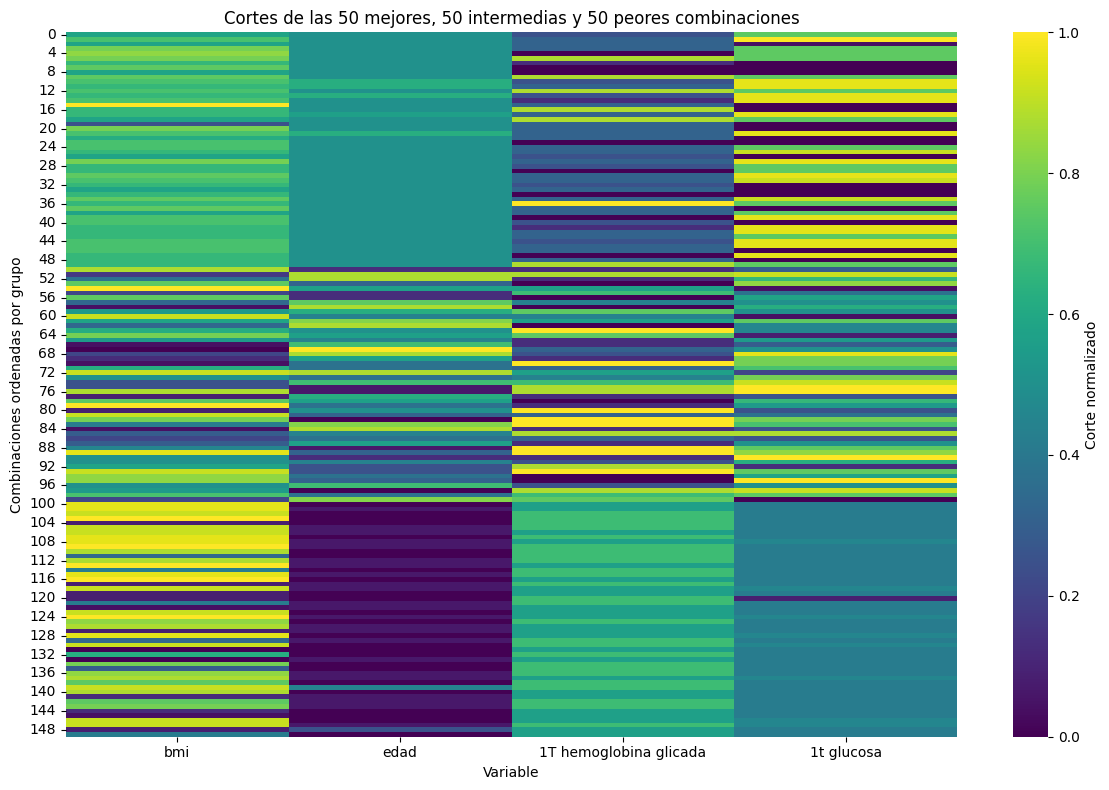

In [57]:
# Muestreo estratificado por rendimiento para representar la evolución global
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df4 = pd.DataFrame(grid4.cv_results_)
top_idx = np.argsort(df4["mean_test_roc_auc"])[::-1]
rows = []
for i in top_idx:
    rows.append({
        "cuts_map": df4["param_binar__cuts_map"][i],
        "mean_roc_auc": df4.loc[i, "mean_test_roc_auc"],
        "mean_pr_auc": df4.loc[i, "mean_test_pr_auc"],
        "mean_f1": df4.loc[i, "mean_test_f1"]
    })

df_4ejes = pd.DataFrame(rows).sort_values("mean_roc_auc", ascending=False).reset_index(drop=True)

df_results = df_4ejes.copy()  # debe tener cuts_map y mean_roc_auc

# Comprobación básica
required_cols = {"cuts_map", "mean_roc_auc"}
missing = required_cols - set(df_results.columns)
if missing:
    raise ValueError(f"Faltan columnas requeridas: {missing}")

# Ordenar por rendimiento
df_sorted = df_results.sort_values("mean_roc_auc", ascending=False).reset_index(drop=True)

# Selección de grupos
n_each = 50
df_top = df_sorted.head(n_each).copy()

mid_start = max(0, len(df_sorted)//2 - n_each//2)
df_mid = df_sorted.iloc[mid_start:mid_start + n_each].copy()

df_bottom = df_sorted.tail(n_each).copy()

# Etiquetar grupos
df_top["grupo"] = "Top 50"
df_mid["grupo"] = "Middle 50"
df_bottom["grupo"] = "Bottom 50"

df_sel = pd.concat([df_top, df_mid, df_bottom], axis=0).reset_index(drop=True)

# Expandir cuts_map a columnas
cuts_expanded = pd.json_normalize(df_sel["cuts_map"])
df_plot = pd.concat([df_sel.drop(columns=["cuts_map"]), cuts_expanded], axis=1)

# Normalizar cada corte para visualizar mejor
cut_cols = list(cuts_expanded.columns)
df_scaled = df_plot.copy()
for col in cut_cols:
    min_v = df_scaled[col].min()
    max_v = df_scaled[col].max()
    if max_v > min_v:
        df_scaled[col] = (df_scaled[col] - min_v) / (max_v - min_v)
    else:
        df_scaled[col] = 0.5

# Ordenar por grupo y rendimiento
df_scaled = df_scaled.sort_values(["grupo", "mean_roc_auc"], ascending=[True, False]).reset_index(drop=True)

# Heatmap con separación visual por grupo
plt.figure(figsize=(12, 8))
sns.heatmap(
    df_scaled[cut_cols],
    cmap="viridis",
    cbar_kws={"label": "Corte normalizado"},
    linewidths=0,
    linecolor="white"
)
plt.title("Cortes de las 50 mejores, 50 intermedias y 50 peores combinaciones")
plt.xlabel("Variable")
plt.ylabel("Combinaciones ordenadas por grupo")
plt.tight_layout()
plt.show()

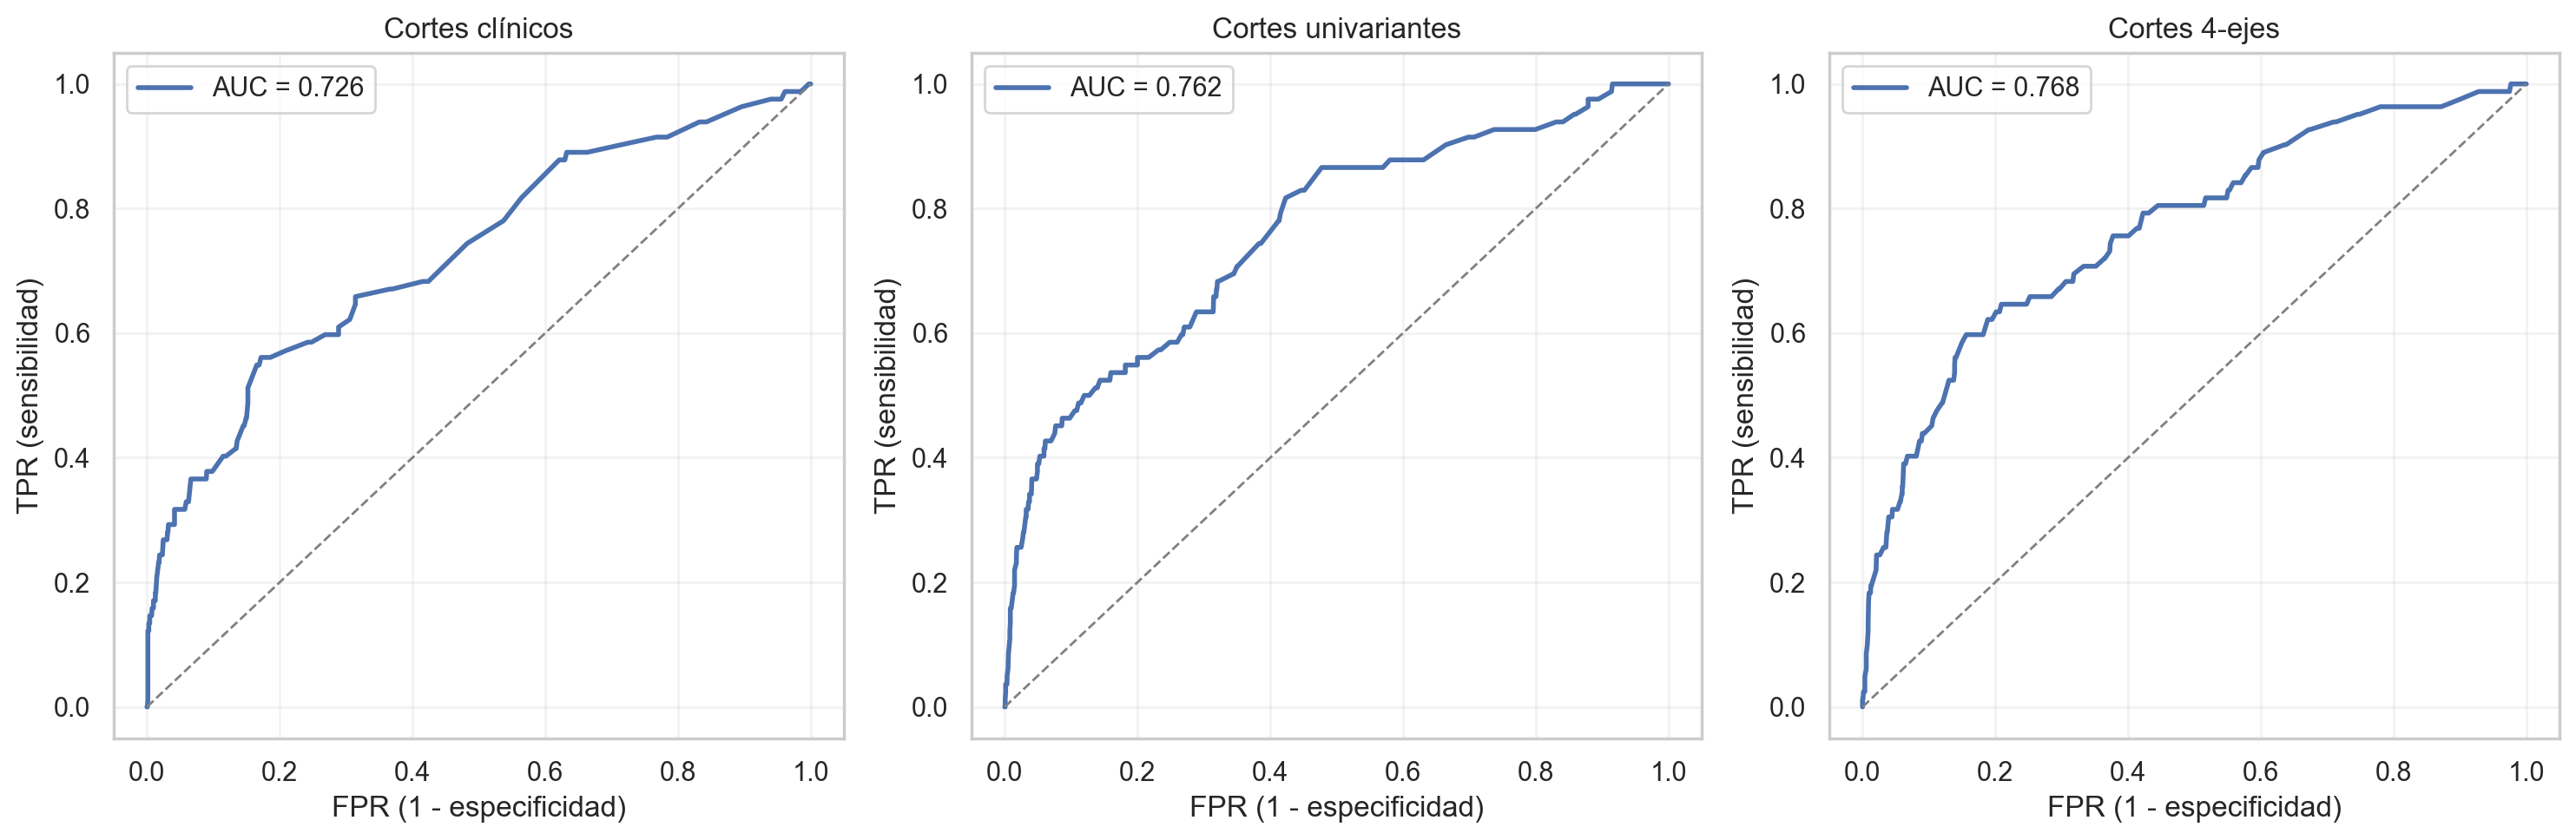

In [168]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score, roc_curve

# Cortes
cuts_clinicos = {
    "bmi": 30,
    "edad": 35,
    "1T hemoglobina glicada": 5.7,
    "1t glucosa": 100
}

cuts_univariantes = {
    "bmi": refined_bmi,
    "edad": refined_edad,
    "1T hemoglobina glicada": refined_hba1c,
    "1t glucosa": refined_gluc
}

cuts_4ejes = {
    "bmi": 30.2,
    "edad": 25.0,
    "1T hemoglobina glicada": 5.4,
    "1t glucosa": 81.0
}

if "build_pipeline_lr" not in globals():
    raise NameError("Falta ejecutar antes la celda que define build_pipeline_lr")

class MultiThresholdBinarizer(BaseEstimator, TransformerMixin):
    def __init__(self, cuts_map=None):
        self.cuts_map = cuts_map or {}

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X2 = X.copy()
        for col, thr in self.cuts_map.items():
            if col in X2.columns and thr is not None:
                vals = pd.to_numeric(X2[col], errors="coerce")
                X2[col] = (vals >= float(thr)).astype(int).fillna(0)
        return X2

def construir_pipe_fair(cuts_map, builder_func, X_df):
    return Pipeline([
        ("binar", MultiThresholdBinarizer(cuts_map=cuts_map)),
        ("model", builder_func(X_df))
    ])

methods = [
    ("Cortes clínicos", cuts_clinicos),
    ("Cortes univariantes", cuts_univariantes),
    ("Cortes 4-ejes", cuts_4ejes),
]

cv_plot = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

plt.rcParams["figure.dpi"] = 200
plt.rcParams["savefig.dpi"] = 300

fig, axes = plt.subplots(1, 3, figsize=(15, 5), dpi=200, constrained_layout=True)

for ax, (name, cuts_map) in zip(axes, methods):
    pipe = construir_pipe_fair(cuts_map=cuts_map, builder_func=build_pipeline_lr, X_df=X_train)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        y_proba_cv = cross_val_predict(
            pipe,
            X_train,
            y_train,
            cv=cv_plot,
            method="predict_proba",
            n_jobs=-1
        )[:, 1]

    fpr, tpr, _ = roc_curve(y_train, y_proba_cv)
    auc = roc_auc_score(y_train, y_proba_cv)

    ax.plot(fpr, tpr, lw=2, label=f"AUC = {auc:.3f}")
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
    ax.set_title(name)
    ax.set_xlabel("FPR (1 - especificidad)")
    ax.set_ylabel("TPR (sensibilidad)")
    ax.legend()
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()